In [1]:
import copy
import hashlib
import json
import math
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
import ruptures as rpt

In [31]:
filepath = '../Datasets/MiningProcess_Flotation_Plant_Database.csv'
TARGET = ['% Iron Concentrate', '% Silica Concentrate']  # columnas a predecir
HORIZON = 1  # horas -- se predice el valor de TARGET dentro de HORIZON horas

# --- Flags de configuracion del pipeline ---
# REMOVE_INITIAL_WEIRD_RANGE: si True, elimina el tramo 2017-03-10 01:00 a
# 2017-03-29 11:01 (hueco/tramo anomalo tras el resampleo). Si False, se
# conserva integro y no se recorta nada del dataset por fecha.
REMOVE_INITIAL_WEIRD_RANGE = False

# USE_COMPOSITE_FEATURES: si True (comportamiento original), las columnas
# fuertemente correlacionadas se combinan en su media (Air Flow 6_7_Mean,
# Air Flow 1_2_3_Mean, Feed Iron_Silica_Mean, Level 4_5_6_7_Mean,
# Level 1_2_3_Mean) y las originales se eliminan. Si False, se mantienen
# todas las columnas originales del dataset sin combinar ni eliminar nada.
USE_COMPOSITE_FEATURES = False

df = pd.read_csv(filepath, decimal=',')
df['date'] = pd.to_datetime(df['date'])

# Columnas de laboratorio: se miden una vez por hora y aparecen repetidas en el CSV
# crudo en cada fila de 20s de esa hora (no son 180 medidas independientes).
lab_cols = ['% Iron Feed', '% Silica Feed', '% Iron Concentrate', '% Silica Concentrate']
sensor_cols = [c for c in df.columns if c not in ['date'] + lab_cols]


In [32]:
# --- 1. Fix the Time Index (The Crucial Step) ---
# df.groupby('date').cumcount() counts the position of each duplicate (0 to 179)
# We multiply that position by 20 seconds and add it to the base timestamp
time_offsets = pd.to_timedelta(df.groupby('date').cumcount() * 20, unit='s')

# Build a precise timeline from the 'date' column + offset (the row index itself
# is just 0..N-1, it is not a datetime, so we cannot add timedeltas to it directly)
df.index = df['date'] + time_offsets

# --- 2. Filter the Bad Range (controlado por REMOVE_INITIAL_WEIRD_RANGE) ---
if REMOVE_INITIAL_WEIRD_RANGE:
    start_remove = '2017-03-10 01:00:00'
    end_remove = '2017-03-29 11:01:00'

    # Create mask and apply it
    mask = (df.index < start_remove) | (df.index > end_remove)
    df = df[mask]

    # Drop the empty 19-day gap created by resampling
    df = df.dropna()
else:
    print("REMOVE_INITIAL_WEIRD_RANGE=False: se conserva el tramo 2017-03-10 a 2017-03-29 sin recortar.")


REMOVE_INITIAL_WEIRD_RANGE=False: se conserva el tramo 2017-03-10 a 2017-03-29 sin recortar.


In [33]:
# Limpieza de outliers por ventana
numeric_df = df.select_dtypes(include=[np.number])

# #### windowed outlier detection using rolling IQR
window_size = 180 # Adjust based on your signal's frequency

# # Calculate rolling quartiles
Q1_rolling = numeric_df.rolling(window=window_size, center=True).quantile(0.25)
Q3_rolling = numeric_df.rolling(window=window_size, center=True).quantile(0.75)
IQR_rolling = Q3_rolling - Q1_rolling

# Calculate dynamic bounds
lower_bound_rolling = Q1_rolling - 1.5 * IQR_rolling
upper_bound_rolling = Q3_rolling + 1.5 * IQR_rolling

# En vez de descartar la fila entera cuando una sola columna se sale de rango,
# recortamos (winsorize) cada valor a su limite mas cercano: perdemos el valor
# extremo pero conservamos la fila y el resto de columnas de esa lectura.
n_outliers = ((numeric_df < lower_bound_rolling) | (numeric_df > upper_bound_rolling)).sum().sum()
df[numeric_df.columns] = numeric_df.clip(lower=lower_bound_rolling, upper=upper_bound_rolling, axis=0)

print(f"Row count: {len(df)}")
print(f"Valores recortados (winsorized): {n_outliers}")

Row count: 737453
Valores recortados (winsorized): 312937


In [34]:
# Promedia senales con alta correlacion (controlado por USE_COMPOSITE_FEATURES)
air_flow_6_7 = [
    'Flotation Column 06 Air Flow', 
    'Flotation Column 07 Air Flow'
]

air_flow_1_2_3 = [
    'Flotation Column 01 Air Flow', 
    'Flotation Column 02 Air Flow', 
    'Flotation Column 03 Air Flow'
]

silica_iron_feed = [
    '% Iron Feed',  
    '% Silica Feed'
]

level_4_5_6_7 = [
    'Flotation Column 04 Level',  
    'Flotation Column 05 Level',
    'Flotation Column 06 Level',  
    'Flotation Column 07 Level'
]

level_1_2_3 = [
    'Flotation Column 01 Level',  
    'Flotation Column 02 Level',
    'Flotation Column 03 Level'
]

if USE_COMPOSITE_FEATURES:
    # Calculate the row-wise mean for each group and assign to new columns
    df['Air Flow 6_7_Mean'] = df[air_flow_6_7].mean(axis=1)
    df['Air Flow 1_2_3_Mean'] = df[air_flow_1_2_3].mean(axis=1)
    df['Feed Iron_Silica_Mean'] = df[silica_iron_feed].mean(axis=1)
    df['Level 4_5_6_7_Mean'] = df[level_4_5_6_7].mean(axis=1)
    df['Level 1_2_3_Mean'] = df[level_1_2_3].mean(axis=1)

    # Combine the lists and drop the original features
    columns_to_drop = air_flow_6_7 + air_flow_1_2_3 + silica_iron_feed + level_4_5_6_7 + level_1_2_3
    df = df.drop(columns=columns_to_drop)

    # '% Iron Feed' y '% Silica Feed' se fusionaron en 'Feed Iron_Silica_Mean';
    # actualizamos lab_cols para que siga reflejando las columnas de laboratorio reales.
    lab_cols = [c for c in lab_cols if c not in silica_iron_feed] + ['Feed Iron_Silica_Mean']
else:
    print("USE_COMPOSITE_FEATURES=False: se mantienen todas las columnas originales sin combinar.")

# sensor_cols se recalcula contra las columnas reales de df: con
# USE_COMPOSITE_FEATURES=True incluye las combinadas (Air Flow 6_7_Mean,
# Air Flow 1_2_3_Mean, Level ..._Mean); con False incluye las originales
# sin combinar (df y lab_cols no se tocaron en la rama else).
sensor_cols = [c for c in df.columns if c not in ['date'] + lab_cols]

# Version sin features (solo media horaria por sensor, sin slope/std) para
# visualizacion externa. Distinta del df de trabajo: no se modifica df aqui.
agg_viz = {c: 'mean' for c in sensor_cols}
agg_viz.update({c: 'first' for c in lab_cols})
df_viz = df.groupby('date', as_index=True).agg(agg_viz).sort_index()
df_viz.to_csv('forecasting_data_historical.csv', index=True)


USE_COMPOSITE_FEATURES=False: se mantienen todas las columnas originales sin combinar.


In [35]:
# Antes de agregar a resolucion horaria: para cada sensor rapido calculamos,
# sobre los ultimos 30 puntos (de 20s) de cada hora, la media, la pendiente de
# regresion lineal (tendencia dentro de la hora) y la desviacion estandar.
# Estas 3 features capturan mas informacion que un simple promedio horario.
def _slope(y):
    y = y.to_numpy()
    n = len(y)
    if n < 2:
        return np.nan
    x = np.arange(n)
    return np.polyfit(x, y, 1)[0]

last30 = df.groupby('date')[sensor_cols].tail(30).groupby(df['date'])
feat_mean = last30.mean().add_suffix('_mean')
feat_slope = last30.apply(lambda g: g.apply(_slope)).add_suffix('_slope')
feat_std = last30.std().add_suffix('_std')

sensor_features = pd.concat([feat_mean, feat_slope, feat_std], axis=1)

# Agregamos a resolucion horaria: 'first' para las columnas de laboratorio
# (todas las filas de la hora ya comparten el mismo valor); los sensores
# rapidos ya se resumieron arriba en sensor_features (media/pendiente/std).
agg = {c: 'first' for c in lab_cols}
df = df.groupby('date', as_index=True).agg(agg).sort_index()
df = df.join(sensor_features)
print(f"File parameters: {df.columns}")
# Rellenamos huecos horarios que falten en el indice (haberlos hay: la campana no
# es perfectamente continua) e interpolamos linealmente.
full_range = pd.date_range(df.index.min(), df.index.max(), freq='h')
n_missing_hours = len(full_range.difference(df.index))
print(f"Missing hours in original index: {n_missing_hours}")
df = df.reindex(full_range)

for c in df.columns:
    if df[c].isna().any():
        df[c] = df[c].ffill()

print(f"Filas (horas): {len(df)} | horas que faltaban en el indice original y se rellenaron: {n_missing_hours}")
print(df[TARGET].describe())

File parameters: Index(['% Iron Feed', '% Silica Feed', '% Iron Concentrate',
       '% Silica Concentrate', 'Starch Flow_mean', 'Amina Flow_mean',
       'Ore Pulp Flow_mean', 'Ore Pulp pH_mean', 'Ore Pulp Density_mean',
       'Flotation Column 01 Air Flow_mean',
       'Flotation Column 02 Air Flow_mean',
       'Flotation Column 03 Air Flow_mean',
       'Flotation Column 04 Air Flow_mean',
       'Flotation Column 05 Air Flow_mean',
       'Flotation Column 06 Air Flow_mean',
       'Flotation Column 07 Air Flow_mean', 'Flotation Column 01 Level_mean',
       'Flotation Column 02 Level_mean', 'Flotation Column 03 Level_mean',
       'Flotation Column 04 Level_mean', 'Flotation Column 05 Level_mean',
       'Flotation Column 06 Level_mean', 'Flotation Column 07 Level_mean',
       'Starch Flow_slope', 'Amina Flow_slope', 'Ore Pulp Flow_slope',
       'Ore Pulp pH_slope', 'Ore Pulp Density_slope',
       'Flotation Column 01 Air Flow_slope',
       'Flotation Column 02 Air Flow_slop

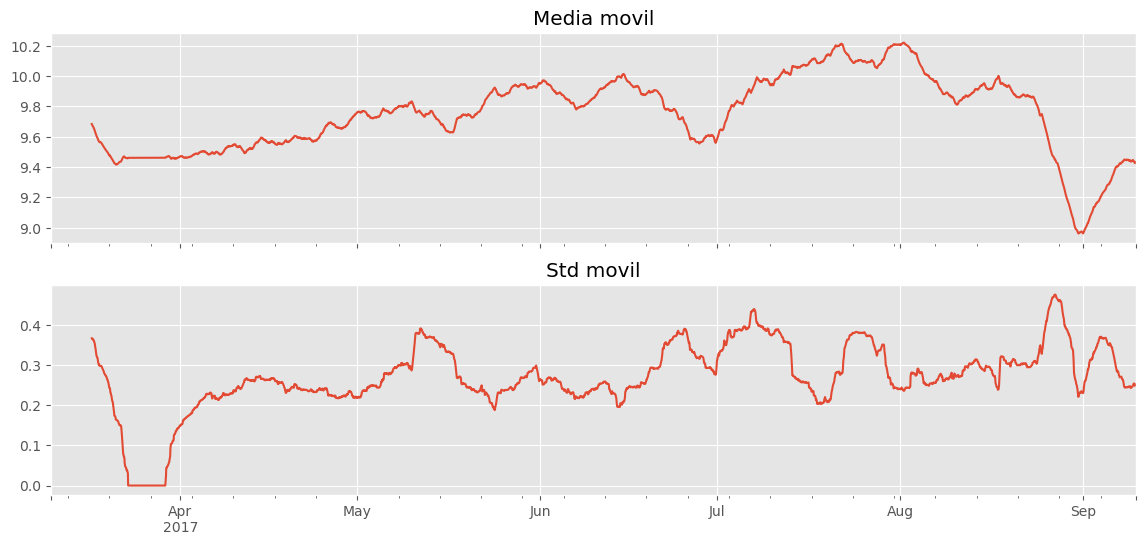

                start                 end  duration_h      mean       std
2 2017-08-23 17:00:00 2017-09-09 23:00:00       414.0  9.242198  0.333710
0 2017-03-10 01:00:00 2017-05-17 08:00:00      1639.0  9.609649  0.277066
1 2017-05-17 09:00:00 2017-08-23 16:00:00      2359.0  9.928336  0.326914
Regimenes totales: 3, tras filtrar < 24h: 3
                start                 end  duration_h      mean       std
0 2017-03-10 01:00:00 2017-05-17 08:00:00      1639.0  9.609649  0.277066
1 2017-05-17 09:00:00 2017-08-23 16:00:00      2359.0  9.928336  0.326914
2 2017-08-23 17:00:00 2017-09-09 23:00:00       414.0  9.242198  0.333710


In [36]:
# Check if signals are stationary (mean and variance do not change over time)
# Usa el df ya agregado a resolucion horaria (celda de agregacion mas arriba):
# window=24*7 son 168 horas = 1 semana.
window = 24*7  # una semana, ajustable
chosen_pen = 50

rolling_mean = df['Ore Pulp pH_mean'].rolling(window).mean()
rolling_std = df['Ore Pulp pH_mean'].rolling(window).std()

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
rolling_mean.plot(ax=axes[0], title='Media movil')
rolling_std.plot(ax=axes[1], title='Std movil')
plt.show()

def regime_durations(serie, bps):
    """bps son indices de posicion (los que devuelve algo.predict), no fechas"""
    edges = [0] + bps  # incluye el inicio
    regimes = []
    for i in range(len(edges)-1):
        start_idx, end_idx = edges[i], edges[i+1]
        start_date = serie.index[start_idx]
        end_date = serie.index[end_idx-1]
        duration_h = (end_date - start_date).total_seconds() / 3600
        regimes.append({
            'start': start_date, 'end': end_date, 'duration_h': duration_h,
            'mean': serie.iloc[start_idx:end_idx].mean(),
            'std': serie.iloc[start_idx:end_idx].std(),
        })
    return pd.DataFrame(regimes)

col = 'Ore Pulp pH_mean'
serie = df[col].dropna()
signal = serie.values
algo = rpt.Pelt(model="l2").fit(signal)
bps = algo.predict(pen=chosen_pen)

reg_df = regime_durations(serie, bps)
print(reg_df.sort_values('duration_h'))

MIN_REGIME_HOURS = 24

reg_df_filtered = reg_df[reg_df['duration_h'] >= MIN_REGIME_HOURS]
print(f'Regimenes totales: {len(reg_df)}, tras filtrar < {MIN_REGIME_HOURS}h: {len(reg_df_filtered)}')
print(reg_df_filtered)

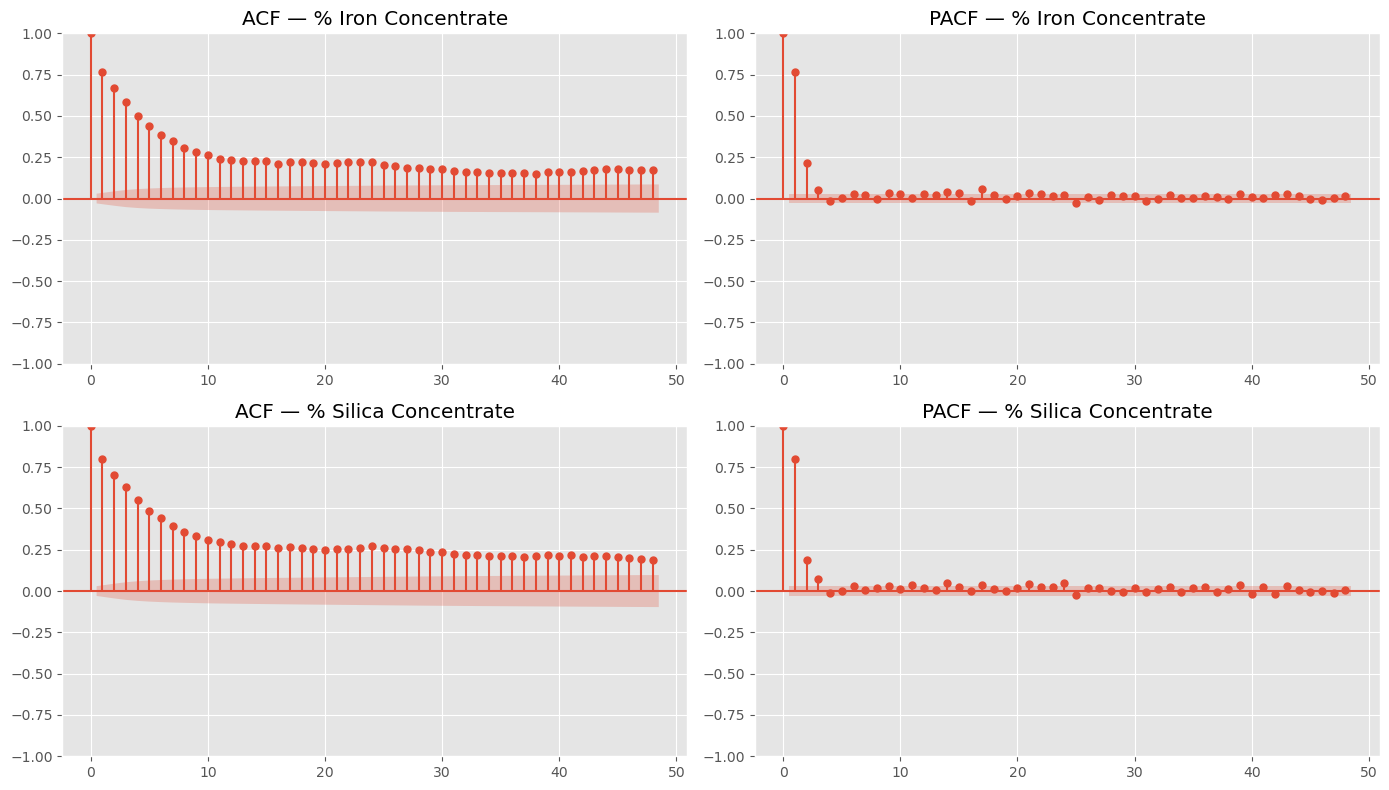

In [37]:
# --- Autocorrelacion (ACF) y autocorrelacion parcial (PACF) de los targets ---
# Se mira esto ANTES de cualquier analisis de correlacion cruzada con los
# sensores: caracteriza cuanta memoria temporal tiene cada target por si
# solo (cuanto explica el pasado del propio target sobre su futuro), lo cual
# es relevante para:
# - Interpretar los umbrales de ruido de MI/xcorr calculados mas abajo: un
#   target con autocorrelacion fuerte hace que el shuffle puro (que rompe
#   toda la memoria) subestime el ruido de fondo (ver celda de umbral por
#   permutacion vs. desplazamiento circular).
# - Decidir si merece la pena anadir lags del propio target como feature
#   (autoregresivo) ademas de los sensores exogenos.
#
# OJO al interpretar: TARGET son medidas de laboratorio de baja frecuencia
# propagadas hacia adelante (ffill) para rellenar la rejilla horaria (ver
# celda anterior). Eso infla artificialmente la autocorrelacion en los
# primeros lags (rachas de valor identico por construccion, no porque el
# proceso tenga esa memoria) -- la ACF/PACF de aqui describe la serie TAL
# COMO ENTRA al modelo (con el ffill ya aplicado), no la dinamica real del
# proceso entre mediciones de laboratorio.
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

ACF_LAGS = 48  # horas (2 dias) de horizonte para ver memoria de corto/medio plazo

fig, axes = plt.subplots(len(TARGET), 2, figsize=(14, 4 * len(TARGET)))
for i, target_col in enumerate(TARGET):
    series = df[target_col].dropna()

    ax_acf = axes[i, 0] if len(TARGET) > 1 else axes[0]
    plot_acf(series, lags=ACF_LAGS, ax=ax_acf, title=f'ACF — {target_col}')

    ax_pacf = axes[i, 1] if len(TARGET) > 1 else axes[1]
    plot_pacf(series, lags=ACF_LAGS, ax=ax_pacf, method='ywm', title=f'PACF — {target_col}')

plt.tight_layout()
plt.show()


In [38]:
# Comprobar la correlacion entre las señales target y las features de laboratorio
# Para cada variable de proceso candidata (elige 3-5 que físicamente deberían
# tener relación causal directa y rápida con sílice/iron, ej. % feed, flujo de aire)
def cross_correlation_lag(sensor, target, max_lag_hours=6):
    sensor_norm = (sensor - sensor.mean()) / sensor.std()
    target_norm = (target - target.mean()) / target.std()
    correlations = []
    for lag in range(-max_lag_hours, max_lag_hours + 1):
        if lag < 0:
            c = np.corrcoef(sensor_norm[:lag], target_norm[-lag:])[0, 1]
        elif lag > 0:
            c = np.corrcoef(sensor_norm[lag:], target_norm[:-lag])[0, 1]
        else:
            c = np.corrcoef(sensor_norm, target_norm)[0, 1]
        correlations.append((lag, c))
    return correlations

for target in TARGET:
    print(f"\nCross-correlation for target: {target}")
    for sensor in df.columns:

        if not "mean" in sensor:
            continue
        correlations = cross_correlation_lag(df[sensor], df[target])

        max_corr = max(correlations, key=lambda x: abs(x[1]))
        print(f"Max correlation in {sensor} at lag {max_corr[0]} hours: {max_corr[1]:.4f}")



Cross-correlation for target: % Iron Concentrate
Max correlation in Starch Flow_mean at lag 4 hours: 0.0770
Max correlation in Amina Flow_mean at lag 2 hours: -0.1350
Max correlation in Ore Pulp Flow_mean at lag -6 hours: 0.0853
Max correlation in Ore Pulp pH_mean at lag -4 hours: 0.2480
Max correlation in Ore Pulp Density_mean at lag 5 hours: 0.0589
Max correlation in Flotation Column 01 Air Flow_mean at lag -3 hours: 0.1665
Max correlation in Flotation Column 02 Air Flow_mean at lag -3 hours: 0.1214
Max correlation in Flotation Column 03 Air Flow_mean at lag -3 hours: 0.1717
Max correlation in Flotation Column 04 Air Flow_mean at lag -3 hours: 0.0469
Max correlation in Flotation Column 05 Air Flow_mean at lag 6 hours: -0.0493
Max correlation in Flotation Column 06 Air Flow_mean at lag -4 hours: 0.0608
Max correlation in Flotation Column 07 Air Flow_mean at lag -4 hours: 0.0957
Max correlation in Flotation Column 01 Level_mean at lag -5 hours: -0.0467
Max correlation in Flotation Col

In [39]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import mutual_info_regression


def _mask_frozen_target(df, target_col, min_run_hours):
    """Devuelve una copia de df[target_col] con NaN en las horas que
    pertenecen a una racha de valor CONSTANTE de min_run_hours horas o mas.

    Importante: pone NaN en el TARGET unicamente -- nunca en los sensores de
    entrada. Un sensor de proceso constante durante horas es una lectura de
    proceso valida (ej. una variable manipulada que no se ha tocado), no un
    artefacto; poner NaN ahi tambien introduciria sesgo. El target aqui es
    una medida de laboratorio de baja frecuencia propagada hacia adelante
    (ffill) para rellenar la rejilla horaria -- sus rachas constantes son
    ese ffill funcionando como se diseño, y hay que excluirlas para no medir
    la relacion sensor-target contra un valor que en realidad no cambio
    porque no se volvio a medir (no porque el proceso estuviera realmente en
    ese valor exacto en cada una de esas horas).

    Se pone NaN (no se elimina la fila) para que la rejilla horaria se
    mantenga completa y continua: asi, al comparar un lag distinto de 0, el
    desplazamiento .shift(lag) opera sobre una rejilla sin huecos y el
    conjunto de instantes de TARGET validos es el mismo para todos los lags
    (cambia unicamente que sensor(t-lag) le corresponde a cada uno). Si en
    vez de esto se eliminaran filas, el numero de pares validos variaria de
    forma no controlada de un lag a otro.
    """
    is_repeated = df[target_col].diff() == 0
    run_id = (~is_repeated).cumsum()
    run_lengths = df.groupby(run_id)[target_col].transform('size')
    frozen = run_lengths >= min_run_hours
    target_masked = df[target_col].where(~frozen)
    return target_masked, frozen


def _check_hourly_grid(df):
    """Verifica que el indice sea una rejilla horaria completa y sin huecos
    (precondicion para que los shifts por pd.Timedelta(hours=lag) comparen
    siempre la hora correcta, sin necesidad de reindexar en cada llamada)."""
    full_range = pd.date_range(df.index.min(), df.index.max(), freq='h')
    missing = full_range.difference(df.index)
    if len(missing) > 0:
        raise ValueError(
            f"El indice no es una rejilla horaria continua: faltan {len(missing)} horas "
            f"(ej. {missing[:3].tolist()}). Reindexa/rellena antes de medir correlacion cruzada."
        )
    if not df.index.is_monotonic_increasing:
        raise ValueError("El indice no esta ordenado ascendentemente.")


def cross_correlation_clean(df, sensor_col, target_col, max_lag_hours=6,
                              min_run_hours=12):
    """
    Cross-correlation entre sensor y target por lag horario.

    - El target se pone a NaN (no se elimina la fila) en las horas que
      pertenecen a una racha constante de min_run_hours horas o mas (ver
      _mask_frozen_target). El sensor NUNCA se filtra: sus valores
      constantes son proceso valido.
    - Requiere una rejilla horaria completa (ver _check_hourly_grid) para
      que el shift por Timedelta(hours=lag) siempre alinee la hora correcta.
    - dropna() se aplica DESPUES de alinear sensor y target desplazados, y
      con la MISMA mascara de target (independiente del lag): el conjunto de
      horas de target validas es identico en todos los lags, asi que n_pairs
      es comparable entre lags salvo por los NaN que arrastre el propio
      sensor (que aqui no debería tener, al no filtrarse).
    """
    _check_hourly_grid(df)
    df = df.sort_index()

    target_masked, _ = _mask_frozen_target(df, target_col, min_run_hours)
    sensor = df[sensor_col]

    correlations = []
    for lag in range(-max_lag_hours, max_lag_hours + 1):
        # sensor(t - lag) se compara con target(t): lag>0 => el sensor va
        # 'lag' horas por delante del target (input adelantado, causal);
        # lag<0 => el sensor va por detras.
        sensor_shifted = sensor.shift(lag)
        valid_pairs = pd.concat([sensor_shifted, target_masked], axis=1).dropna()
        n_pairs = len(valid_pairs)
        if n_pairs < 30:
            correlations.append((lag, np.nan, n_pairs))
            continue
        c = np.corrcoef(valid_pairs.iloc[:, 0], valid_pairs.iloc[:, 1])[0, 1]
        correlations.append((lag, c, n_pairs))

    return pd.DataFrame(correlations, columns=['lag_hours', 'correlation', 'n_pairs'])


def mutual_info_by_lag(df, sensor_col, target_col, max_lag_hours=6,
                        min_run_hours=12, random_state=21):
    """Informacion mutua (no lineal, sin signo) entre sensor y target por
    lag. Mismo criterio de mascara de target y misma rejilla horaria que
    cross_correlation_clean, para que ambos metodos se evaluen sobre
    exactamente los mismos pares por lag."""
    _check_hourly_grid(df)
    df = df.sort_index()

    target_masked, _ = _mask_frozen_target(df, target_col, min_run_hours)
    sensor = df[sensor_col]

    mi_rows = []
    for lag in range(-max_lag_hours, max_lag_hours + 1):
        sensor_shifted = sensor.shift(lag)
        valid_pairs = pd.concat([sensor_shifted, target_masked], axis=1).dropna()
        n_pairs = len(valid_pairs)
        if n_pairs < 30:
            mi_rows.append((lag, np.nan, n_pairs))
            continue
        mi = mutual_info_regression(
            valid_pairs.iloc[:, [0]], valid_pairs.iloc[:, 1], random_state=random_state)[0]
        mi_rows.append((lag, mi, n_pairs))

    return pd.DataFrame(mi_rows, columns=['lag_hours', 'mutual_info', 'n_pairs'])


# Uso: se prueban las candidatas originales en sus 3 variantes (_mean,
# _slope, _std) para ver si la pendiente o la dispersion dentro de la hora
# aportan mas relacion con el target que el simple promedio horario.
# Con USE_COMPOSITE_FEATURES=False, 'Level 4_5_6_7_Mean' no existe: se
# sustituye por las 4 columnas originales de ese grupo.
if USE_COMPOSITE_FEATURES:
    base_sensors = ['Amina Flow', 'Level 4_5_6_7_Mean', 'Starch Flow', 'Ore Pulp pH']
else:
    base_sensors = ['Amina Flow', 'Starch Flow', 'Ore Pulp pH'] + level_4_5_6_7
sensor_cols = [f'{s}_{suffix}' for s in base_sensors for suffix in ('mean', 'slope', 'std')]
targets = ['% Iron Concentrate', '% Silica Concentrate']  # lista de columnas de target

n_tests = len(sensor_cols) * 13 * len(targets)  # 13 = lags de -6 a 6
bonferroni_threshold_n = 30  # ajusta según tu tamaño de muestra real tras filtrar
# calcula el umbral de significancia real con scipy.stats si quieres ser riguroso

summary_rows = []
for target_name in targets:
    print(f"\n=== {target_name} ===")
    for sensor_col in sensor_cols:
        if sensor_col not in df.columns:
            print(f"\nSensor: {sensor_col} -- no existe en df, se omite")
            continue
        print(f"\nSensor: {sensor_col}")
        res = cross_correlation_clean(df, sensor_col, target_name,
                                        max_lag_hours=6, min_run_hours=12)
        print(res)
        best_xcorr = res.loc[res['correlation'].abs().idxmax()]

        mi_res = mutual_info_by_lag(df, sensor_col, target_name,
                                      max_lag_hours=6, min_run_hours=12)
        print(mi_res)
        best_mi = mi_res.loc[mi_res['mutual_info'].idxmax()]

        summary_rows.append({
            'target': target_name,
            'sensor': sensor_col,
            'variante': sensor_col.rsplit('_', 1)[-1],
            'best_lag_xcorr': best_xcorr['lag_hours'],
            'abs_correlation': abs(best_xcorr['correlation']),
            'correlation': best_xcorr['correlation'],
            'n_pairs_xcorr': best_xcorr['n_pairs'],
            'best_lag_mi': best_mi['lag_hours'],
            'mutual_info': best_mi['mutual_info'],
        })

# --- Resumen: compara mean vs slope vs std para cada sensor base y target,
# con ambos criterios (correlacion lineal + informacion mutua no lineal) uno
# al lado del otro. Ordenado por |xcorr| de mayor a menor; si mutual_info es
# alto pero abs_correlation es bajo para una variante, sugiere una relacion
# no lineal o no monotona que la correlacion cruzada no puede capturar.
summary_df = pd.DataFrame(summary_rows).sort_values(['target', 'abs_correlation'], ascending=[True, False])
print("\n=== Resumen: mejor lag, correlacion e informacion mutua por variante ===")
print(summary_df.to_string(index=False))



=== % Iron Concentrate ===

Sensor: Amina Flow_mean
    lag_hours  correlation  n_pairs
0          -6    -0.164124     3793
1          -5    -0.183881     3794
2          -4    -0.210464     3795
3          -3    -0.228336     3796
4          -2    -0.233937     3797
5          -1    -0.193617     3798
6           0    -0.159971     3799
7           1    -0.132137     3798
8           2    -0.092729     3797
9           3    -0.069627     3796
10          4    -0.057282     3795
11          5    -0.040011     3794
12          6    -0.040968     3793
    lag_hours  mutual_info  n_pairs
0          -6     0.015317     3793
1          -5     0.041107     3794
2          -4     0.065890     3795
3          -3     0.040722     3796
4          -2     0.063258     3797
5          -1     0.000000     3798
6           0     0.025728     3799
7           1     0.040897     3798
8           2     0.023676     3797
9           3     0.013529     3796
10          4     0.006645     3795
11         

              target                              input  best_lag_xcorr  |xcorr|  best_lag_mi       mi
  % Iron Concentrate                      % Silica Feed               3 0.041253            0 0.590379
  % Iron Concentrate                        % Iron Feed               3 0.015629            3 0.583301
  % Iron Concentrate                     Amina Flow_std               1 0.207093            0 0.445231
  % Iron Concentrate                    Starch Flow_std               1 0.066906            0 0.430166
  % Iron Concentrate             Ore Pulp Density_slope               5 0.067847            0 0.426626
  % Iron Concentrate               Ore Pulp Density_std               6 0.089661            0 0.426440
  % Iron Concentrate     Flotation Column 03 Level_mean               3 0.066185            0 0.417812
  % Iron Concentrate     Flotation Column 02 Level_mean               2 0.052250            0 0.397686
  % Iron Concentrate                   Amina Flow_slope               4 0

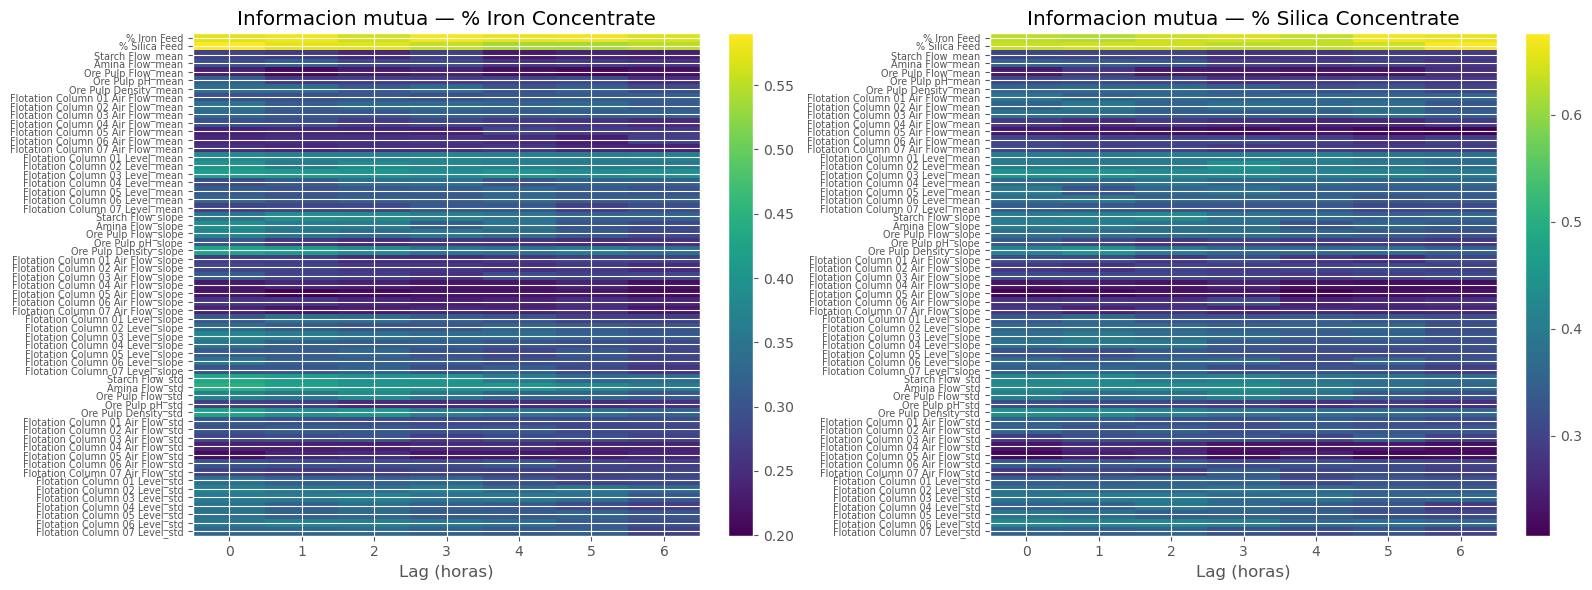

% Iron Concentrate: L (decorrelacion < 0.2) = 25 horas
% Silica Concentrate: L (decorrelacion < 0.2) = 63 horas

--- % Iron Concentrate ---


KeyboardInterrupt: 

In [40]:
# --- Correlacion cruzada + informacion mutua vs. lag, por señal de entrada ---
# Objetivo: para cada parametro de entrada -- sensores + columnas de
# laboratorio, en sus 3 variantes por hora (_mean, _slope, _std) -- ver a
# que lag esta mas relacionado con cada target y con que fuerza, para decidir
# que variante y lag merece la pena meter como input al modelo.
#
# - Correlacion cruzada (lineal, con signo): corr(input(t-lag), target(t))
# - Informacion mutua (no lineal, sin signo): capta cualquier dependencia,
#   incluida no monotona, pero no dice si la relacion es directa o inversa.
#
# Se usa df (agregacion horaria CON _mean/_slope/_std) y SOLO el tramo de
# train para no filtrar informacion del test en la seleccion de lags.
from sklearn.feature_selection import mutual_info_regression

# input_cols viene de 'df' (agregacion horaria CON features derivadas:
# _mean/_slope/_std por sensor), no de df_viz (que solo tiene la media simple)
# -- asi entran al analisis tambien la pendiente y la dispersion dentro de
# cada hora, no solo el promedio, y compiten las 3 variantes entre si por
# senal y lag.
MAX_LAG = 6  # horas
input_cols = [c for c in df.columns if c not in TARGET]

train_cutoff = df.index[int(len(df) * 0.70)]
mi_train = df.loc[:train_cutoff]

xcorr_results = {t: pd.DataFrame(index=input_cols, columns=range(MAX_LAG + 1), dtype=float) for t in TARGET}
mi_results = {t: pd.DataFrame(index=input_cols, columns=range(MAX_LAG + 1), dtype=float) for t in TARGET}

for target_col in TARGET:
    y = mi_train[target_col]
    for lag in range(MAX_LAG + 1):
        shifted = mi_train[input_cols].shift(lag)
        valid = shifted.join(y, how='inner').dropna()
        if len(valid) < 30:
            continue
        X_lag = valid[input_cols]
        y_lag = valid[target_col]

        xcorr_results[target_col][lag] = X_lag.corrwith(y_lag)

        mi = mutual_info_regression(X_lag, y_lag, random_state=21)
        mi_results[target_col][lag] = mi

# --- Mejor lag por señal segun cada criterio ---
summary_rows = []
for target_col in TARGET:
    best_xcorr_lag = xcorr_results[target_col].abs().idxmax(axis=1)
    best_xcorr_val = xcorr_results[target_col].abs().max(axis=1)
    best_mi_lag = mi_results[target_col].idxmax(axis=1)
    best_mi_val = mi_results[target_col].max(axis=1)
    for col in input_cols:
        summary_rows.append({
            'target': target_col,
            'input': col,
            'best_lag_xcorr': best_xcorr_lag[col],
            '|xcorr|': best_xcorr_val[col],
            'best_lag_mi': best_mi_lag[col],
            'mi': best_mi_val[col],
        })

summary = pd.DataFrame(summary_rows).sort_values(['target', 'mi'], ascending=[True, False])
print(summary.to_string(index=False))

# --- Heatmaps: fuerza de relacion (MI) por señal x lag, un heatmap por target ---
fig, axes = plt.subplots(1, len(TARGET), figsize=(8 * len(TARGET), 6))
for ax, target_col in zip(axes, TARGET):
    im = ax.imshow(mi_results[target_col].values, aspect='auto', cmap='viridis')
    ax.set_yticks(range(len(input_cols)))
    ax.set_yticklabels(input_cols, fontsize=7)
    ax.set_xticks(range(MAX_LAG + 1))
    ax.set_xlabel('Lag (horas)')
    ax.set_title(f'Informacion mutua — {target_col}')
    fig.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.show()

# --- Umbral de ruido por permutacion: MI que se obtendria por puro azar ---
# La MI estimada por k-NN nunca es exactamente 0 aunque no haya relacion real,
# asi que no hay un umbral absoluto "bueno". Para saber si un MI observado es
# plausible (no ruido de estimacion) lo comparamos contra la distribucion de MI
# que se obtiene barajando el target (rompe la relacion temporal real) muchas
# veces: cualquier MI observado por debajo del percentil 95 de ese ruido no es
# distinguible de una relacion espuria.
N_PERMUTATIONS = 500
# rng = np.random.default_rng(21)
# noise_mi = {t: [] for t in TARGET}

# for target_col in TARGET:
#     y = mi_train[target_col].dropna()
#     X = mi_train.loc[y.index, input_cols]
#     for _ in range(N_PERMUTATIONS):
#         y_shuffled = rng.permutation(y.values)
#         mi_noise = mutual_info_regression(X, y_shuffled, random_state=21)
#         noise_mi[target_col].append(mi_noise.max())  # el maximo entre señales es el criterio mas estricto

# noise_threshold = {t: np.percentile(noise_mi[t], 95) for t in TARGET}
# print('Umbral de ruido (MI, percentil 95 sobre target barajado):')
# for t in TARGET:
#     print(f'  {t}: {noise_threshold[t]:.4f}')


# --- Umbral de ruido alternativo: DESPLAZAMIENTO CIRCULAR EN BLOQUE ---
# El shuffle puro de arriba destruye TODA la autocorrelacion del target, asi
# que si el target tiene autocorrelacion fuerte (es tipico en variables de
# proceso que cambian lento hora a hora), el shuffle puro genera una serie
# "demasiado aleatoria" comparada con el target real, y puede subestimar el
# ruido de fondo (umbral artificialmente bajo -> falsos positivos al elegir
# senales). El desplazamiento circular (block circular shift) rota la serie
# completa un numero aleatorio de posiciones (wrap-around): la autocorrelacion
# interna del target se preserva intacta, pero se rompe la relacion temporal
# especifica con cada input. Es el metodo recomendado para umbrales de
# significancia en series temporales (Politis & Romano, block bootstrap).
# --- Calculo de L: horas hasta que el target se decorrela (ACF < 0.2) ---
# Un shift circular menor que L produce una serie casi identica a la original
# (por la autocorrelacion propia del proceso), lo que infla artificialmente
# el umbral de ruido. L se calcula por target, no se fija a ojo.
from statsmodels.tsa.stattools import acf

L_per_target = {}
for target_col in TARGET:
    y = mi_train[target_col].dropna()
    acf_vals = acf(y, nlags=min(72, len(y) // 4))
    below_02 = np.where(acf_vals < 0.2)[0]
    L_per_target[target_col] = int(below_02[0]) if len(below_02) > 0 else 24  # fallback conservador
    print(f'{target_col}: L (decorrelacion < 0.2) = {L_per_target[target_col]} horas')

# --- Umbral de ruido: DESPLAZAMIENTO CIRCULAR EN BLOQUE, nulo del maximo ---
# sobre columnas Y lags simultaneamente (cubre el espacio de busqueda real
# de la seleccion final: 7 lags x N columnas, no solo columnas a lag fijo).
# Shift restringido a [L, n-L] para no generar rotaciones casi identicas al
# target real cuando este tiene autocorrelacion fuerte.
#
# COSTE: N_PERMUTATIONS x (MAX_LAG+1) llamadas a mutual_info_regression.
# Con N_PERMUTATIONS=500 y MAX_LAG=6 -> 3500 llamadas por target. Si tarda
# demasiado en una primera pasada, baja N_PERMUTATIONS a 100 para validar
# que el pipeline corre bien, y sube a 500+ solo para el resultado final.

rng_circ = np.random.default_rng(21)
noise_threshold_circ = {}

for target_col in TARGET:
    print(f'\n--- {target_col} ---')
    y = mi_train[target_col].dropna()
    n = len(y)
    L = L_per_target[target_col]

    if n - L <= L:
        raise ValueError(
            f'{target_col}: L={L} deja un rango de shift vacio o invertido '
            f'(n={n}). Revisa la ACF o reduce el rango de nlags.'
        )

    max_mi_per_rep = []
    for i in range(N_PERMUTATIONS):
        shift = rng_circ.integers(L, n - L)
        y_circ = pd.Series(np.roll(y.values, shift), index=y.index)

        rep_max = 0.0
        for lag in range(MAX_LAG + 1):
            shifted = mi_train[input_cols].shift(lag)
            valid = shifted.join(y_circ.rename(target_col), how='inner').dropna()
            if len(valid) < 30:
                continue
            mi = mutual_info_regression(
                valid[input_cols], valid[target_col], random_state=21
            ).max()
            rep_max = max(rep_max, mi)

        max_mi_per_rep.append(rep_max)

        if (i + 1) % 100 == 0:
            print(f'  permutacion {i + 1}/{N_PERMUTATIONS}')

    noise_threshold_circ[target_col] = np.percentile(max_mi_per_rep, 95)

print('\nUmbral de ruido (MI, percentil 95, circular shift, nulo del maximo sobre columnas x lags):')
for t in TARGET:
    print(f'  {t}: {noise_threshold_circ[t]:.4f}  (L={L_per_target[t]}h)')

# --- Comparativa: cuanto difieren ambos metodos de umbral ---
# Si el circular da un umbral notablemente MAYOR que el shuffle puro, es
# senal de que el target tiene autocorrelacion relevante y el shuffle puro
# estaba siendo demasiado laxo (dejaria pasar senales que en realidad no
# aportan mas MI que la que da la propia inercia temporal del target).
# print('\nComparativa umbrales (shuffle puro vs. circular shift):')
# for t in TARGET:
#     diff_pct = (noise_threshold_circ[t] / noise_threshold[t] - 1) * 100
#     print(f'  {t}: shuffle={noise_threshold[t]:.4f}  circular={noise_threshold_circ[t]:.4f}  '
#           f'diferencia={diff_pct:+.1f}%')

# --- Seleccion final: 3 pares (señal, lag) GLOBALES, señales distintas entre si,
# con MI por encima del umbral de ruido, ordenados de mayor a menor MI. Para
# combinar ambos targets se recorren los candidatos de los dos a la vez y se
# toma, por cada señal, el mejor par (target, lag) que aparezca primero en el
# ranking conjunto.
candidates = []
for target_col in TARGET:
    for col in input_cols:
        for lag in range(MAX_LAG + 1):
            mi_val = mi_results[target_col].loc[col, lag]
            if pd.notna(mi_val) and mi_val >= noise_threshold_circ[target_col]:
                candidates.append({'input': col, 'lag': lag, 'target': target_col, 'mi': mi_val})

candidates_df = pd.DataFrame(candidates).sort_values('mi', ascending=False)

selected = []
used_inputs = set()
for _, row in candidates_df.iterrows():
    if row['input'] in used_inputs:
        continue
    selected.append(row)
    used_inputs.add(row['input'])
    if len(selected) == 3:
        break

selected_lags = pd.DataFrame(selected)[['input', 'lag', 'target', 'mi']].reset_index(drop=True)
print('\n3 lags plausibles seleccionados (orden de mayor a menor MI validado):')
print(selected_lags.to_string(index=False))

In [41]:
# --- Mejores valores de MI en lag=0 (relacion instantanea, misma hora) ---
# lag=0 es el caso "nowcasting": el input y el target se miden en la MISMA
# hora, sin desfase temporal. Interesa aislarlo porque una senal con MI alta
# solo en lag=0 no sirve para forecasting real (en produccion no tienes el
# target de la hora actual para usarlo como feature) -- hay que compararlo
# con su mejor lag>0 (ya visto en 'summary' de la celda anterior) para saber
# si aporta algo mas alla de la relacion instantanea.
mi_lag0_rows = []
for target_col in TARGET:
    for col in input_cols:
        mi_val = mi_results[target_col].loc[col, 0]
        if pd.notna(mi_val):
            mi_lag0_rows.append({'target': target_col, 'input': col, 'mi_lag0': mi_val})

mi_lag0_df = pd.DataFrame(mi_lag0_rows).sort_values(['target', 'mi_lag0'], ascending=[True, False])

print('=== Mejores MI en lag=0, por target ===')
for target_col in TARGET:
    print(f'\n--- {target_col} ---')
    print(mi_lag0_df[mi_lag0_df['target'] == target_col].head(10).to_string(index=False))


=== Mejores MI en lag=0, por target ===

--- % Iron Concentrate ---
            target                          input  mi_lag0
% Iron Concentrate                  % Silica Feed 0.590379
% Iron Concentrate                    % Iron Feed 0.572773
% Iron Concentrate                 Amina Flow_std 0.445231
% Iron Concentrate                Starch Flow_std 0.430166
% Iron Concentrate         Ore Pulp Density_slope 0.426626
% Iron Concentrate           Ore Pulp Density_std 0.426440
% Iron Concentrate Flotation Column 03 Level_mean 0.417812
% Iron Concentrate Flotation Column 02 Level_mean 0.397686
% Iron Concentrate               Amina Flow_slope 0.393612
% Iron Concentrate Flotation Column 01 Level_mean 0.382716

--- % Silica Concentrate ---
              target                          input  mi_lag0
% Silica Concentrate                  % Silica Feed 0.633980
% Silica Concentrate                    % Iron Feed 0.627248
% Silica Concentrate Flotation Column 03 Level_mean 0.448469
% Silica 

In [42]:
# --- 2. Features reducidas: SOLO estas, nada mas ---
# Con USE_COMPOSITE_FEATURES=False, las columnas compuestas no existen:
# se sustituyen por sus equivalentes originales (Feed Iron_Silica_Mean ->
# % Iron Feed + % Silica Feed; Air Flow 1_2_3_Mean_mean -> las 3 columnas
# individuales de ese grupo en su variante _mean).
if USE_COMPOSITE_FEATURES:
    FEATURE_COLS_LAG_0 = [
        'Feed Iron_Silica_Mean',
        'Ore Pulp Density_slope',
        'Ore Pulp Density_std',
        'Starch Flow_std',
        'Amina Flow_std',
        'Amina Flow_slope'
    ]
        # 'Ore Pulp Density_mean',
        # 'Flotation Column 05 Air Flow_mean',
        # 'Amina Flow_mean'

    FEATURE_COLS_LAG_1 = [
        'Feed Iron_Silica_Mean',
        'Air Flow 1_2_3_Mean_mean',
        'Ore Pulp Density_mean'
    ]
else:
    FEATURE_COLS_LAG_0 = [
        '% Iron Feed',
        '% Silica Feed',
        'Ore Pulp Density_slope',
        'Ore Pulp Density_std',
        'Starch Flow_std',
        'Amina Flow_std',
        'Amina Flow_slope'
    ]

    FEATURE_COLS_LAG_1 = [
        '% Iron Feed',
        '% Silica Feed',
        'Flotation Column 01 Air Flow_mean',
        'Flotation Column 02 Air Flow_mean',
        'Flotation Column 03 Air Flow_mean',
        'Ore Pulp Density_mean'
    ]

FEATURE_COLS_LAG_3 = [
    'Ore Pulp pH_mean'
]

lag_per_feature = {
    0: FEATURE_COLS_LAG_0,
    1: FEATURE_COLS_LAG_1,
    3: FEATURE_COLS_LAG_3
}

# Construir cada lag de forma separada y luego concatenarlas para tener un X final con todas las features y sus lags
for lag, features in lag_per_feature.items():
    lagged_features = df[features].shift(lag)
    lagged_features.columns = [f"{c}_lag{lag}" for c in lagged_features.columns]
    
    if lag == 0:
        X_all = lagged_features
    else:
        X_all = pd.concat([X_all, lagged_features], axis=1)


# # Construir X con lag 1 explicito para TODAS las features (incluido el propio target)
# X_all = df[FEATURE_COLS].shift(1)   # todo lo disponible en t-1
# X_all.columns = [f"{c}_lag1" for c in X_all.columns]

y_all = df[TARGET].copy()  # target real en t (que tras el shift de X es t = t-1+1)

# Alinear: quitar la primera fila (sin lag disponible) y cualquier NaN por el filtrado de rachas
valid_rows = X_all.dropna().index.intersection(y_all.dropna().index)
X_all = X_all.loc[valid_rows]
y_all = y_all.loc[valid_rows]


In [43]:
from sklearn.multioutput import MultiOutputRegressor

# # Features = everything except the TARGET (TARGET defined above)
# FEATURE_COLS = [c for c in df.columns if c not in TARGET]

# # Forecasting real a HORIZON horas vista: las features de la fila t describen
# # lo que paso HASTA la hora t (sensores + estadisticos de esa hora), y el target
# # es el valor real medido en t+HORIZON. Sin este shift el modelo estaria hackeando
# # el problema (nowcasting: prediciendo el target de la misma hora que sus features).
# X_all = df[FEATURE_COLS]
# y_all = df[TARGET].shift(-HORIZON)
# y_all = y_all.iloc[:-HORIZON]  # las ultimas HORIZON filas no tienen target futuro conocido
# X_all = X_all.loc[y_all.index]

# Recortamos el dataset para que el test acabe el 1 de agosto: a partir de esa
# fecha las condiciones de proceso cambian y dejan de ser comparables a train.
# TEST_CUTOFF = pd.Timestamp('2017-08-01 00:00:00')
# X_all = X_all.loc[:TEST_CUTOFF]
# y_all = y_all.loc[:TEST_CUTOFF]

# Split temporal (no aleatorio) 70/30 dentro del tramo recortado: los datos son
# series temporales, un split aleatorio dejaria que el modelo entrene con
# vecinos temporales del test (fuga de informacion) e invalidaria la
# comparacion contra los naive baselines.
split_idx = int(len(X_all) * 0.8)
X_train, X_test = X_all.iloc[:split_idx], X_all.iloc[split_idx:]
y_train, y_test = y_all.iloc[:split_idx], y_all.iloc[split_idx:]

# z-score normalization: z = (x - mu) / sigma, fit on train only to avoid leakage
X_mean, X_std = X_train.mean(), X_train.std()
X_train_scaled = (X_train - X_mean) / X_std
X_test_scaled = (X_test - X_mean) / X_std

xgb_params = dict(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.01,
    random_state=21,
)

model = MultiOutputRegressor(XGBRegressor(**xgb_params, n_jobs=-1, tree_method='hist'))
model.fit(X_train_scaled, y_train)
y_pred_train_model = pd.DataFrame(model.predict(X_train_scaled), index=y_train.index, columns=TARGET)
y_pred_model = pd.DataFrame(model.predict(X_test_scaled), index=y_test.index, columns=TARGET)

print('Train shape:', X_train_scaled.shape, ' Test shape:', X_test_scaled.shape)
print('Train range:', X_train.index.min(), '->', X_train.index.max())
print('Test range: ', X_test.index.min(), '->', X_test.index.max())
print(f'Target shifted -{HORIZON}h: fila t -> features(t), target = valor real en t+{HORIZON}h')

Train shape: (3529, 14)  Test shape: (883, 14)
Train range: 2017-03-10 04:00:00 -> 2017-08-04 04:00:00
Test range:  2017-08-04 05:00:00 -> 2017-09-09 23:00:00
Target shifted -1h: fila t -> features(t), target = valor real en t+1h


In [44]:
# --- Grid search de hiperparametros XGBoost con validacion temporal ---
# TimeSeriesSplit en vez de KFold/GridSearchCV aleatorio: cada fold de validacion
# es siempre POSTERIOR en el tiempo a su fold de entrenamiento (igual que el
# split 70/30 de arriba), para no filtrar informacion futura al elegir hiperparametros.
# Se busca solo sobre X_train_scaled/y_train; X_test/y_test se deja intacto para
# la evaluacion final (celdas de naive baselines de mas abajo).
#
# Grid deliberadamente pequeño (3x3x3x2x2 = 108 combinaciones): con ~3120 filas
# de train, un grid grande solo añade ruido de busqueda sin mejorar la señal.
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

param_grid = {
    'estimator__max_depth': [3, 4, 6],
    'estimator__learning_rate': [0.01, 0.03, 0.1],
    'estimator__n_estimators': [200, 300, 500],
    'estimator__subsample': [0.8, 1.0],
    'estimator__colsample_bytree': [0.8, 1.0],
}

# Walk-forward con ventana DESLIZANTE (no expanding): train y val avanzan
# juntos a lo largo del dataset manteniendo SIEMPRE la proporcion 80/20,
# en vez de TimeSeriesSplit (que fija el tamano de val y deja crecer el
# train, asi que el ratio val/train solo es 80/20 en el ultimo fold).
#
# TRAIN_SIZE=1200, VAL_SIZE=240 (exactamente 20% de TRAIN_SIZE) -> con un
# paso igual a VAL_SIZE (folds de validacion consecutivos, sin solapar)
# esto da 8 folds que recorren todo el tramo de train.
TRAIN_SIZE = 1200
VAL_SIZE = int(TRAIN_SIZE * 0.2)
STEP = VAL_SIZE


def walk_forward_splits(n_rows, train_size=TRAIN_SIZE, val_size=VAL_SIZE, step=STEP):
    start = 0
    while start + train_size + val_size <= n_rows:
        tr_idx = np.arange(start, start + train_size)
        va_idx = np.arange(start + train_size, start + train_size + val_size)
        yield tr_idx, va_idx
        start += step


cv_splits = list(walk_forward_splits(len(X_train_scaled)))
print(f'{len(cv_splits)} folds, train={TRAIN_SIZE} val={VAL_SIZE} (ratio val/train={VAL_SIZE / TRAIN_SIZE:.0%}) siempre')
for fold_num, (tr_idx, va_idx) in enumerate(cv_splits, start=1):
    print(f'Fold {fold_num}: train={len(tr_idx)} val={len(va_idx)} '
          f'(val/train={len(va_idx) / len(tr_idx):.1%})')

tscv = cv_splits  # GridSearchCV acepta una lista de (train_idx, val_idx) directamente como cv

base_estimator = MultiOutputRegressor(
    XGBRegressor(random_state=21, n_jobs=-1, tree_method='hist')
)

# neg_RMSE porque GridSearchCV siempre maximiza el score; con salida multioutput
# sklearn promedia el MSE de las columnas de TARGET antes de invertir el signo.
grid_search = GridSearchCV(
    estimator=base_estimator,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',
    cv=tscv,
    n_jobs=-1,
    verbose=1,
)

grid_search.fit(X_train_scaled, y_train)

print('Mejores hiperparametros:', grid_search.best_params_)
print('Mejor RMSE (CV, promedio folds):', -grid_search.best_score_)

# --- Top-10 combinaciones probadas, para ver que tan sensible es el resultado
# a cada hiperparametro (y no quedarnos solo con el ganador puntual) ---
cv_results = pd.DataFrame(grid_search.cv_results_)
top10 = cv_results.sort_values('rank_test_score').head(10).copy()
top10['RMSE_cv'] = -top10['mean_test_score']
print(top10[['rank_test_score', 'RMSE_cv', 'std_test_score', 'params']].to_string(index=False))

# Sustituimos el modelo de la celda anterior por el mejor encontrado en el grid
# search: las celdas de baselines/graficas de abajo siguen funcionando igual
# porque reusan los mismos nombres (model, y_pred_model, y_pred_train_model).
model = grid_search.best_estimator_
y_pred_train_model = pd.DataFrame(model.predict(X_train_scaled), index=y_train.index, columns=TARGET)
y_pred_model = pd.DataFrame(model.predict(X_test_scaled), index=y_test.index, columns=TARGET)

print('\nRMSE test tras grid search:')
for col in TARGET:
    rmse_test = mean_squared_error(y_test[col], y_pred_model[col]) ** 0.5
    print(f'  {col}: {rmse_test:.4f}')


9 folds, train=1200 val=240 (ratio val/train=20%) siempre
Fold 1: train=1200 val=240 (val/train=20.0%)
Fold 2: train=1200 val=240 (val/train=20.0%)
Fold 3: train=1200 val=240 (val/train=20.0%)
Fold 4: train=1200 val=240 (val/train=20.0%)
Fold 5: train=1200 val=240 (val/train=20.0%)
Fold 6: train=1200 val=240 (val/train=20.0%)
Fold 7: train=1200 val=240 (val/train=20.0%)
Fold 8: train=1200 val=240 (val/train=20.0%)
Fold 9: train=1200 val=240 (val/train=20.0%)
Fitting 9 folds for each of 108 candidates, totalling 972 fits
Mejores hiperparametros: {'estimator__colsample_bytree': 1.0, 'estimator__learning_rate': 0.01, 'estimator__max_depth': 3, 'estimator__n_estimators': 200, 'estimator__subsample': 0.8}
Mejor RMSE (CV, promedio folds): 1.0459566844834223
 rank_test_score  RMSE_cv  std_test_score                                                                                                                                                         params
               1 1.045957        0.15

 fold           val_start             val_end  n_train  n_val               target     RMSE      MAE        R2
    1 2017-04-29 04:00:00 2017-05-09 03:00:00     1200    240   % Iron Concentrate 1.145950 0.904753 -0.150441
    1 2017-04-29 04:00:00 2017-05-09 03:00:00     1200    240 % Silica Concentrate 1.144490 0.925240 -0.235436
    2 2017-05-09 04:00:00 2017-05-19 03:00:00     1200    240   % Iron Concentrate 1.179989 0.988208 -0.013687
    2 2017-05-09 04:00:00 2017-05-19 03:00:00     1200    240 % Silica Concentrate 1.429677 1.232934 -0.201773
    3 2017-05-19 04:00:00 2017-05-29 03:00:00     1200    240   % Iron Concentrate 1.154742 0.964975 -0.186577
    3 2017-05-19 04:00:00 2017-05-29 03:00:00     1200    240 % Silica Concentrate 1.304023 1.214885 -0.616246
    4 2017-05-29 04:00:00 2017-06-08 03:00:00     1200    240   % Iron Concentrate 1.257348 1.061783 -0.361912
    4 2017-05-29 04:00:00 2017-06-08 03:00:00     1200    240 % Silica Concentrate 0.928579 0.776166 -0.193245
 

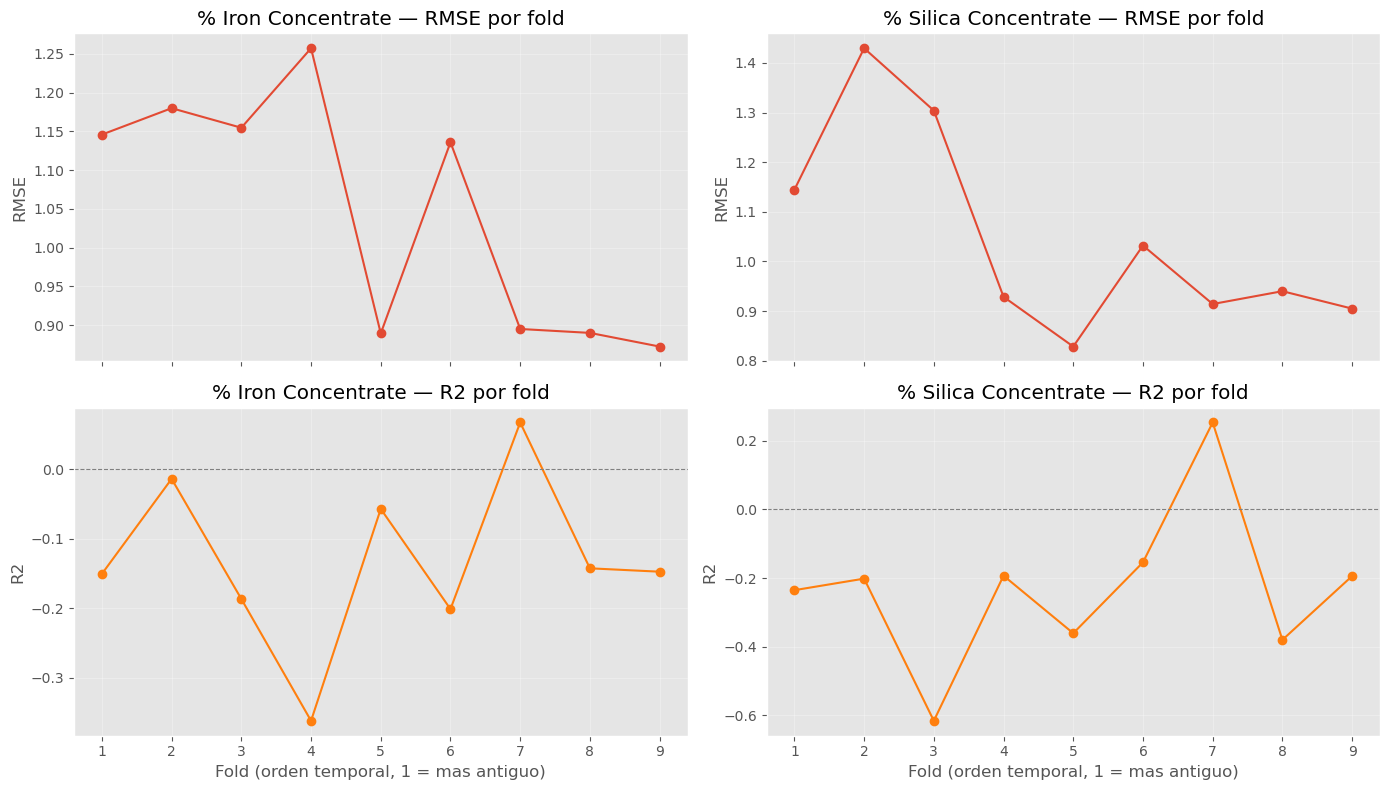

In [45]:
# --- Backtest de ventana deslizante (rolling-origin, walk-forward) ---
# El grid search de arriba solo da el RMSE PROMEDIADO entre los folds de
# walk-forward: si el modelo mejora o empeora segun avanza la campana, ese
# promedio lo esconde. Aqui reentrenamos con los mejores hiperparametros del
# grid search en cada fold por separado y guardamos el score de cada uno,
# para ver la tendencia fold a fold en vez de un unico numero agregado.
#
# Reusa los mismos folds 'tscv' (lista de (train_idx, val_idx)) definidos en
# la celda de grid search: ventana DESLIZANTE de tamano fijo (TRAIN_SIZE/
# VAL_SIZE), no expanding, así que la proporcion val/train es 80/20 en TODOS
# los folds, no solo en el ultimo.

best_params_flat = {k.replace('estimator__', ''): v for k, v in grid_search.best_params_.items()}

rolling_results = []
for fold_num, (train_idx, val_idx) in enumerate(tscv, start=1):
    X_tr, X_val = X_train_scaled.iloc[train_idx], X_train_scaled.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    fold_model = MultiOutputRegressor(
        XGBRegressor(**best_params_flat, random_state=21, n_jobs=-1, tree_method='hist')
    )
    fold_model.fit(X_tr, y_tr)
    y_pred_val = pd.DataFrame(fold_model.predict(X_val), index=y_val.index, columns=TARGET)

    for col in TARGET:
        rolling_results.append({
            'fold': fold_num,
            'val_start': X_val.index.min(),
            'val_end': X_val.index.max(),
            'n_train': len(train_idx),
            'n_val': len(val_idx),
            'target': col,
            'RMSE': mean_squared_error(y_val[col], y_pred_val[col]) ** 0.5,
            'MAE': mean_absolute_error(y_val[col], y_pred_val[col]),
            'R2': r2_score(y_val[col], y_pred_val[col]),
        })

rolling_df = pd.DataFrame(rolling_results)
print(rolling_df.to_string(index=False))

# --- Grafica: RMSE y R2 por fold, un panel por target ---
# Si el modelo mejora al avanzar en el tiempo (mas historico disponible,
# o el proceso se vuelve mas predecible), el RMSE deberia bajar y el R2
# subir de izquierda a derecha. Una linea plana o que empeora sugiere que
# mas datos de entrenamiento no ayudan (o que el proceso cambia de regimen).
fig, axes = plt.subplots(2, len(TARGET), figsize=(7 * len(TARGET), 8), sharex=True)
for j, col in enumerate(TARGET):
    sub = rolling_df[rolling_df['target'] == col]
    axes[0, j].plot(sub['fold'], sub['RMSE'], marker='o')
    axes[0, j].set_title(f'{col} — RMSE por fold')
    axes[0, j].set_ylabel('RMSE')
    axes[0, j].grid(alpha=0.3)

    axes[1, j].plot(sub['fold'], sub['R2'], marker='o', color='tab:orange')
    axes[1, j].set_title(f'{col} — R2 por fold')
    axes[1, j].set_ylabel('R2')
    axes[1, j].set_xlabel('Fold (orden temporal, 1 = mas antiguo)')
    axes[1, j].axhline(0, color='gray', linewidth=0.8, linestyle='--')
    axes[1, j].grid(alpha=0.3)

plt.tight_layout()
plt.show()


     % Iron Concentrate                                         \
        naive_constante naive_drift xgboost_test xgboost_train   
RMSE           0.817818    1.332478     1.211527      0.983807   
MAE            0.574626    0.959132     0.920638      0.758142   
R2             0.479661   -0.387380    -0.139947      0.192418   

     % Silica Concentrate                                         
          naive_constante naive_drift xgboost_test xgboost_train  
RMSE             0.721721    1.134342     1.171155      0.968851  
MAE              0.445544    0.721381     0.916954      0.761635  
R2               0.631087    0.087758     0.029147      0.280269  


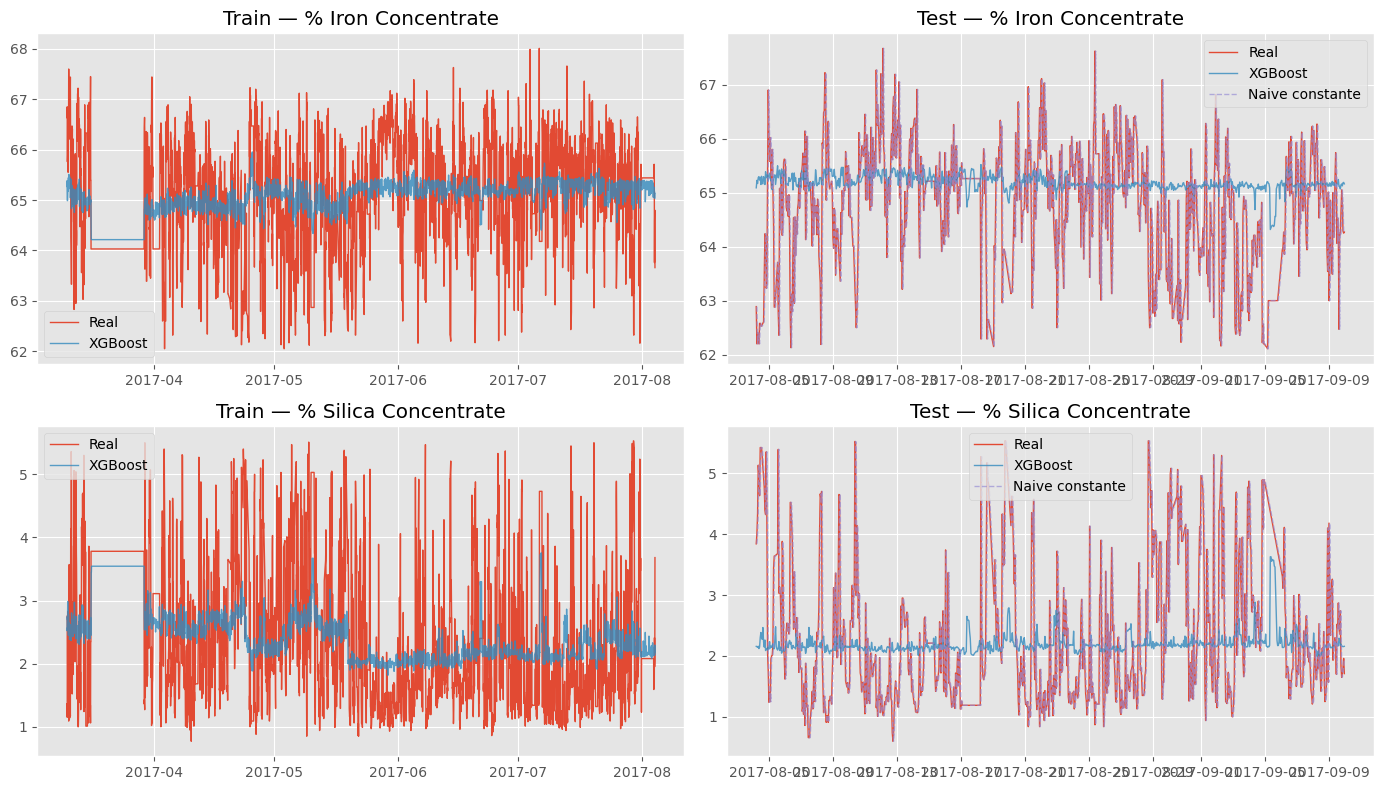

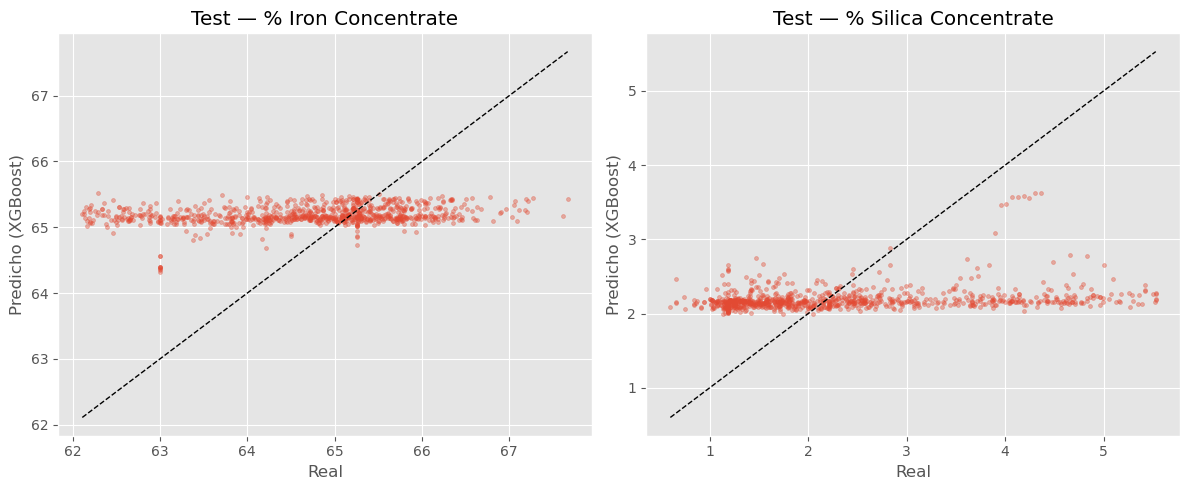

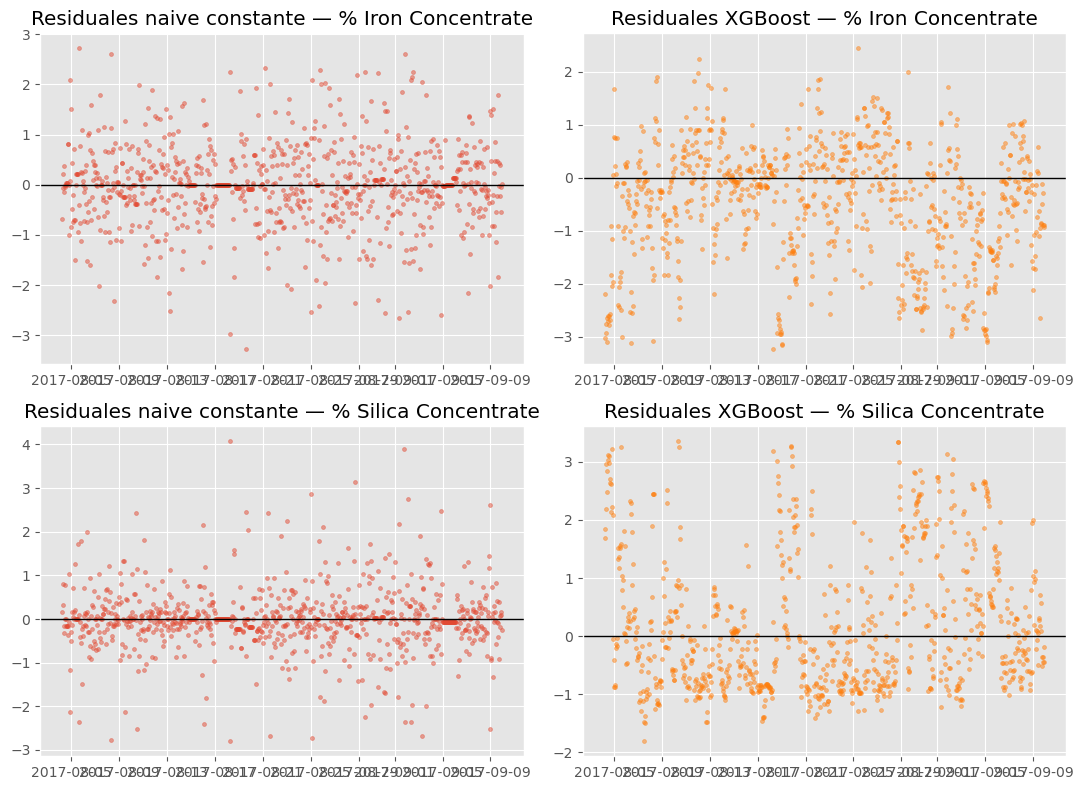

In [46]:
# --- Naive baselines realimentados (persistencia clasica de forecasting a 1 paso):
# usan el valor REAL del target en t (y t-1 para el drift) para predecir t+1, a
# diferencia de un naive "ciego" que no se realimenta. Se evalua sobre el tramo
# de test en resolucion horaria SIN desplazar (df[TARGET], no y_test que ya esta
# shiftado -HORIZON para el XGBoost).
target_series_test = df.loc[X_test.index.min():X_test.index.max(), TARGET]

# ============================================================
# NAIVE CONSTANTE (persistencia): pred(t+1) = target(t)
# ============================================================
def evaluate_naive_constant(df_eval, target_col):
    y_true = df_eval[target_col].iloc[1:].values          # valores reales en t+1
    y_pred = df_eval[target_col].iloc[:-1].values          # prediccion = valor en t
    return y_true, y_pred

# ============================================================
# NAIVE CON DRIFT: pred(t+1) = target(t) + [target(t) - target(t-1)]
# Requiere al menos 2 puntos de historia antes de poder predecir
# ============================================================
def evaluate_naive_drift(df_eval, target_col):
    y = df_eval[target_col].values
    y_true = y[2:]                          # valor real en t+1, empezando desde el 3er punto
    y_t     = y[1:-1]                       # valor en t
    y_t_1   = y[0:-2]                       # valor en t-1
    y_pred  = y_t + (y_t - y_t_1)           # persistencia + tendencia del paso anterior
    return y_true, y_pred

# --- Metricas: RMSE, MAE y R^2 (nunca solo R^2, como exige el criterio del proyecto) ---
naive_results = {}
for col in TARGET:
    yt_c, yp_c = evaluate_naive_constant(target_series_test, col)
    yt_d, yp_d = evaluate_naive_drift(target_series_test, col)

    naive_results[col] = {
        'naive_constante': {
            'RMSE': mean_squared_error(yt_c, yp_c) ** 0.5,
            'MAE': mean_absolute_error(yt_c, yp_c),
            'R2': r2_score(yt_c, yp_c),
        },
        'naive_drift': {
            'RMSE': mean_squared_error(yt_d, yp_d) ** 0.5,
            'MAE': mean_absolute_error(yt_d, yp_d),
            'R2': r2_score(yt_d, yp_d),
        },
        'xgboost_test': {
            'RMSE': mean_squared_error(y_test[col], y_pred_model[col]) ** 0.5,
            'MAE': mean_absolute_error(y_test[col], y_pred_model[col]),
            'R2': r2_score(y_test[col], y_pred_model[col]),
        },
        'xgboost_train': {
            'RMSE': mean_squared_error(y_train[col], y_pred_train_model[col]) ** 0.5,
            'MAE': mean_absolute_error(y_train[col], y_pred_train_model[col]),
            'R2': r2_score(y_train[col], y_pred_train_model[col]),
        },
    }

results = pd.DataFrame({(t, m): naive_results[t][m] for t in naive_results for m in naive_results[t]})
print(results)

# Predicciones naive realineadas al indice del target (para graficar junto al XGBoost)
y_pred_naive_const = pd.DataFrame(
    {col: evaluate_naive_constant(target_series_test, col)[1] for col in TARGET},
    index=target_series_test.index[1:],
)

# --- Graficas de prediccion: real vs. predicho, train y test, por target ---
fig, axes = plt.subplots(len(TARGET), 2, figsize=(14, 4 * len(TARGET)))
for i, col in enumerate(TARGET):
    axes[i, 0].plot(y_train.index, y_train[col], label='Real', linewidth=1)
    axes[i, 0].plot(y_pred_train_model.index, y_pred_train_model[col], label='XGBoost', linewidth=1, alpha=0.8)
    axes[i, 0].set_title(f'Train — {col}')
    axes[i, 0].legend()

    axes[i, 1].plot(y_test.index, y_test[col], label='Real', linewidth=1)
    axes[i, 1].plot(y_pred_model.index, y_pred_model[col], label='XGBoost', linewidth=1, alpha=0.8)
    axes[i, 1].plot(y_pred_naive_const.index, y_pred_naive_const[col], label='Naive constante', linewidth=1, linestyle='--', alpha=0.7)
    axes[i, 1].set_title(f'Test — {col}')
    axes[i, 1].legend()

plt.tight_layout()
plt.show()

# --- Scatter real vs. predicho (test), por target ---
fig, axes = plt.subplots(1, len(TARGET), figsize=(6 * len(TARGET), 5))
for i, col in enumerate(TARGET):
    ax = axes[i]
    ax.scatter(y_test[col], y_pred_model[col], s=8, alpha=0.4)
    lims = [min(y_test[col].min(), y_pred_model[col].min()), max(y_test[col].max(), y_pred_model[col].max())]
    ax.plot(lims, lims, color='black', linewidth=1, linestyle='--')
    ax.set_xlabel('Real')
    ax.set_ylabel('Predicho (XGBoost)')
    ax.set_title(f'Test — {col}')

plt.tight_layout()
plt.show()

# --- Residual plots: modelo vs. naive constante, para cada target ---
fig, axes = plt.subplots(len(TARGET), 2, figsize=(11, 4 * len(TARGET)))
for i, col in enumerate(TARGET):
    resid_naive = target_series_test[col].iloc[1:].values - y_pred_naive_const[col].values
    resid_model = y_test[col] - y_pred_model[col]

    axes[i, 0].scatter(y_pred_naive_const.index, resid_naive, s=8, alpha=0.5)
    axes[i, 0].axhline(0, color='black', linewidth=1)
    axes[i, 0].set_title(f'Residuales naive constante — {col}')

    axes[i, 1].scatter(y_test.index, resid_model, s=8, alpha=0.5, color='tab:orange')
    axes[i, 1].axhline(0, color='black', linewidth=1)
    axes[i, 1].set_title(f'Residuales XGBoost — {col}')

plt.tight_layout()
plt.show()

In [47]:
# --- LSTM (Keras): forecasting a 1 hora, sin las senales target como input ---
# HORIZON=1 (una sola hora adelante, no multi-step). La ventana de entrada
# sigue usando el pasado real de las senales (WINDOW=12 horas anteriores a
# t): cada muestra es (WINDOW, n_features) y su target es el valor real de
# TARGET en t (la hora siguiente al final de la ventana).
#
# Esta celda define el set de features POR DEFECTO (LSTM_FEATURE_COLS, el
# curado a mano de siempre) y una funcion build_lstm_datasets(feature_cols)
# que reconstruye train/test/escalado/ventanas para CUALQUIER lista de
# features. El random search de la celda siguiente varia tambien el set de
# features (top-N por informacion mutua) y necesita poder reconstruir estos
# datasets para cada set sin repetir este bloque a mano.
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

WINDOW = 12    # horas de contexto (pasado) que ve la LSTM en cada muestra
HORIZON = 1    # horas futuras a predecir (1 = una sola hora adelante)

# Con USE_COMPOSITE_FEATURES=False, las columnas compuestas no existen:
# se sustituyen por sus equivalentes originales (ver misma logica que en
# FEATURE_COLS_LAG_0/1 del bloque XGBoost).
if USE_COMPOSITE_FEATURES:
    LSTM_FEATURE_COLS = [
        'Ore Pulp Density_mean',
        'Flotation Column 05 Air Flow_mean',
        'Amina Flow_mean',
        'Feed Iron_Silica_Mean',
        'Air Flow 1_2_3_Mean_mean',
        'Ore Pulp pH_mean',
    ]
else:
    LSTM_FEATURE_COLS = [
        'Ore Pulp Density_mean',
        'Flotation Column 05 Air Flow_mean',
        'Amina Flow_mean',
        '% Iron Feed',
        '% Silica Feed',
        'Flotation Column 01 Air Flow_mean',
        'Flotation Column 02 Air Flow_mean',
        'Flotation Column 03 Air Flow_mean',
        'Ore Pulp pH_mean',
    ]


def make_windows_multistep(raw_df, feature_cols, feat_mean, feat_std, target_mean, target_std,
                            window=WINDOW, horizon=HORIZON):
    """De un DataFrame horario (features + TARGET) construye secuencias de
    entrada (window, n_features) y su target normalizado (horizon,
    n_targets): la ventana [t-window, t) predice los valores de TARGET en
    t, t+1, ..., t+horizon-1. Con horizon=1 esto es un unico paso (t)."""
    feats_scaled = (raw_df[feature_cols] - feat_mean) / feat_std
    target_scaled = (raw_df[TARGET] - target_mean) / target_std
    X_seq, y_seq, idx_seq = [], [], []
    feat_values = feats_scaled.values
    target_values = target_scaled.values
    index = raw_df.index
    # el ultimo i valido es el que deja horizon pasos completos por delante
    for i in range(window, len(raw_df) - horizon + 1):
        X_seq.append(feat_values[i - window:i])
        y_seq.append(target_values[i:i + horizon])
        idx_seq.append(index[i])  # timestamp del primer paso predicho (t)
    return np.array(X_seq), np.array(y_seq), pd.DatetimeIndex(idx_seq)


def build_lstm_datasets(feature_cols, window=WINDOW, horizon=HORIZON):
    """Construye train/test ya ventaneados y escalados para un set de
    features arbitrario. Mismo split temporal (80/20) y mismo criterio de
    escalado (z-score fit SOLO en train, target incluido) que el bloque LSTM
    original -- se centraliza aqui para poder repetirlo por cada feature_set
    del random search sin duplicar la logica de split/escalado/ventaneo.

    El target se normaliza ademas de las features: sin esto, con loss='mae'
    o 'mse' en escala original (~60-68% Iron, ~1-6% Silica) el gradiente
    inicial mas facil de aprovechar es simplemente ajustar el sesgo de la
    capa Dense final hacia la media del target -- eso minimiza la loss
    rapido al principio y, combinado con un EarlyStopping impaciente, deja
    al modelo "congelado" prediciendo casi una constante.
    """
    raw = df[feature_cols + TARGET].dropna()
    split_idx = int(len(raw) * 0.8)
    train_raw = raw.iloc[:split_idx]
    test_raw = raw.iloc[split_idx:]

    feat_mean = train_raw[feature_cols].mean()
    feat_std = train_raw[feature_cols].std()
    target_mean = train_raw[TARGET].mean()
    target_std = train_raw[TARGET].std()

    train_X, train_y_scaled, train_idx = make_windows_multistep(
        train_raw, feature_cols, feat_mean, feat_std, target_mean, target_std,
        window=window, horizon=horizon)
    test_X, test_y_scaled, test_idx = make_windows_multistep(
        test_raw, feature_cols, feat_mean, feat_std, target_mean, target_std,
        window=window, horizon=horizon)

    y_train = train_y_scaled * target_std.values + target_mean.values
    y_test = test_y_scaled * target_std.values + target_mean.values

    return {
        'feature_cols': feature_cols,
        'train_X': train_X, 'train_y_scaled': train_y_scaled, 'train_idx': train_idx,
        'test_X': test_X, 'test_y_scaled': test_y_scaled, 'test_idx': test_idx,
        'y_train': y_train, 'y_test': y_test,
        'feat_mean': feat_mean, 'feat_std': feat_std,
        'target_mean': target_mean, 'target_std': target_std,
    }


# --- Dataset por defecto (LSTM_FEATURE_COLS) ---
# Se mantienen los nombres globales originales (train_X_lstm, lstm_feat_mean,
# etc.) para no romper las celdas de metricas/graficas de mas abajo, que se
# re-sincronizan tras el entrenamiento final con la config ganadora.
_default_ds = build_lstm_datasets(LSTM_FEATURE_COLS)
train_X_lstm, train_y_lstm_scaled, train_idx_lstm = _default_ds['train_X'], _default_ds['train_y_scaled'], _default_ds['train_idx']
test_X_lstm, test_y_lstm_scaled, test_idx_lstm = _default_ds['test_X'], _default_ds['test_y_scaled'], _default_ds['test_idx']
y_train_lstm, y_test_lstm = _default_ds['y_train'], _default_ds['y_test']
lstm_feat_mean, lstm_feat_std = _default_ds['feat_mean'], _default_ds['feat_std']
lstm_target_mean, lstm_target_std = _default_ds['target_mean'], _default_ds['target_std']

n_targets_lstm = len(TARGET)
n_features_lstm = len(LSTM_FEATURE_COLS)

print(f'train_X_lstm: {train_X_lstm.shape}, train_y_lstm_scaled: {train_y_lstm_scaled.shape}')
print(f'test_X_lstm : {test_X_lstm.shape}, test_y_lstm_scaled : {test_y_lstm_scaled.shape}')
print(f'Ventana: {WINDOW}h de contexto -> predice TARGET en la hora siguiente (HORIZON={HORIZON})')


train_X_lstm: (3520, 12, 9), train_y_lstm_scaled: (3520, 1, 2)
test_X_lstm : (871, 12, 9), test_y_lstm_scaled : (871, 1, 2)
Ventana: 12h de contexto -> predice TARGET en la hora siguiente (HORIZON=1)


In [ ]:
# --- Random search de arquitectura/features/optimizacion para la LSTM ---
# Con tantos ejes a la vez (feature-set, forma de la arquitectura, dropout,
# learning_rate, weight_decay, atencion, optimizador, loss) un grid
# cartesiano completo son miles de combinaciones -- inviable en tiempo
# razonable incluso dejando el equipo encendido. Se usa random search: se
# muestrean N_SEARCH combinaciones al azar del espacio conjunto, lo cual
# cubre el espacio con presupuesto de computo acotado y predecible, y a
# diferencia de una busqueda secuencial por etapas SI explora interacciones
# entre ejes (ej. que cierto optimizador rinda mejor solo con cierto
# feature-set).
#
# Ejes del espacio de busqueda:
# - feature_set: TOP-4 / TOP-6 / TOP-8 columnas por informacion mutua media
#   (lag=0, "nowcasting") entre ambos targets, usando mi_results ya
#   calculado en la celda de MI/xcorr mas arriba (no se recalcula MI aqui).
# - n_layers (1-3) + forma piramidal de units: p.ej. con n_layers=3 se
#   muestrea entre (16,16,16) y formas decrecientes tipo (32,16,8).
# - dropout: continuo en [0.1, 0.5]
# - learning_rate: log-uniforme en [1e-4, 5e-3]
# - weight_decay: log-uniforme en [1e-5, 1e-3] (solo aplica si optimizer='adamw')
# - use_attention: True/False (self-attention tras la primera LSTM)
# - optimizer: 'adam' (sin weight decay explicito) / 'adamw'
# - loss: 'mae' / 'mse'
#
# Cada combinacion se entrena con EarlyStopping corto (patience=15) que solo
# sirve para clasificar candidatos por su mejor val_loss -- no hace falta
# paciencia larga para EXPLORAR, solo para el entrenamiento definitivo del
# ganador (ver celda siguiente).
import time

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, LSTM, Dense, Dropout, Reshape,
    MultiHeadAttention, LayerNormalization, Add, GlobalAveragePooling1D,
)
from tensorflow.keras.optimizers import Adam, AdamW
from tensorflow.keras.callbacks import EarlyStopping


def build_lstm(units, dropout, learning_rate, input_shape, horizon, n_targets,
                weight_decay=0.0, use_attention=False, attention_heads=2,
                optimizer='adamw', loss='mae'):
    """units: int (misma capacidad en todas las capas) o tupla/lista con una
    entrada por capa (arquitectura piramidal, ej. (32, 16, 8)). n_layers se
    deriva de len(units) en ese caso."""
    units_per_layer = [units] if isinstance(units, int) else list(units)
    n_layers = len(units_per_layer)

    inputs = Input(shape=input_shape)
    x = inputs
    for i, layer_units in enumerate(units_per_layer):
        is_last_lstm = (i == n_layers - 1)
        # con atencion, TODAS las LSTM devuelven secuencia completa (hace
        # falta la secuencia para que la atencion tenga sobre que operar, y
        # para el GlobalAveragePooling1D final); sin atencion, solo la
        # ultima LSTM colapsa a un vector (comportamiento original).
        return_seq = (not is_last_lstm) or use_attention
        x = LSTM(
            units=layer_units,
            activation='elu' if i == 0 else 'softsign',
            return_sequences=return_seq,
        )(x)
        if use_attention and i == 0:
            attn_out = MultiHeadAttention(
                num_heads=attention_heads, key_dim=max(layer_units // attention_heads, 1)
            )(x, x)
            x = Add()([x, attn_out])  # conexion residual: no reemplaza la salida LSTM, la enriquece
            x = LayerNormalization()(x)
    if use_attention:
        x = GlobalAveragePooling1D()(x)
    x = Dropout(dropout)(x)
    x = Dense(horizon * n_targets)(x)
    outputs = Reshape((horizon, n_targets))(x)

    model = Model(inputs, outputs)
    if optimizer == 'adamw':
        opt = AdamW(learning_rate=learning_rate, weight_decay=weight_decay)
    elif optimizer == 'adam':
        opt = Adam(learning_rate=learning_rate)
    else:
        raise ValueError(f"optimizer desconocido: {optimizer!r} (usa 'adam' o 'adamw')")
    model.compile(loss=loss, optimizer=opt)
    return model


# --- Feature sets candidatos: TOP-N por informacion mutua media (lag=0) ---
# lag=0 (nowcasting) porque la LSTM ya recibe WINDOW=12 horas de pasado real
# de cada senal como contexto secuencial -- no necesita ademas un lag fijo
# aplicado a nivel de columna, a diferencia de FEATURE_COLS_LAG_* de XGBoost.
# mi_results viene de la celda de MI/xcorr mas arriba (dict target -> DataFrame
# input_cols x lag); se promedia entre ambos TARGET para tener un unico ranking.
_mi_lag0_by_target = pd.concat(
    [mi_results[t][0].rename(t) for t in TARGET], axis=1
)
_mi_lag0_mean = _mi_lag0_by_target.mean(axis=1).dropna()
# Se excluyen del ranking las columnas de TARGET (no tiene sentido usar el
# propio target como feature) y cualquier columna que no sea de tipo sensor
# (por construccion input_cols ya excluye TARGET, pero se re-filtra aqui por
# claridad ya que mi_results se calculo sobre TODO input_cols).
_mi_ranking = _mi_lag0_mean[~_mi_lag0_mean.index.isin(TARGET)].sort_values(ascending=False)

print("=== Ranking de features por MI media (lag=0, ambos targets) ===")
print(_mi_ranking.head(10).to_string())

FEATURE_SET_SIZES = [4, 6, 8]
FEATURE_SETS = {n: _mi_ranking.head(n).index.tolist() for n in FEATURE_SET_SIZES}
for n, cols in FEATURE_SETS.items():
    print(f"\nTOP-{n}: {cols}")

# Cache de datasets por feature_set: build_lstm_datasets reconstruye
# train/test/escalado/ventanas (ver celda anterior), y es lo unico que
# cambia con feature_set -- se cachea para no repetir el trabajo si el
# random search muestrea el mismo tamano de feature_set varias veces.
_dataset_cache = {n: build_lstm_datasets(cols) for n, cols in FEATURE_SETS.items()}
for n, ds in _dataset_cache.items():
    print(f"TOP-{n}: train_X={ds['train_X'].shape}, test_X={ds['test_X'].shape}")

# --- Formas piramidales de unidades por n_layers ---
UNIT_SHAPES = {
    1: [(8,), (16,), (32,)],
    2: [(16, 16), (32, 16), (32, 8)],
    3: [(16, 16, 16), (32, 16, 8), (32, 16, 16)],
}

N_SEARCH = 300
SEARCH_EPOCHS = 150
SEARCH_PATIENCE = 15
SEARCH_SEED = 21

rng_search = np.random.default_rng(SEARCH_SEED)


def sample_config(rng):
    n_layers = int(rng.choice([1, 2, 3]))
    units = UNIT_SHAPES[n_layers][rng.integers(len(UNIT_SHAPES[n_layers]))]
    optimizer = rng.choice(['adam', 'adamw'])
    return {
        'feature_set_size': int(rng.choice(FEATURE_SET_SIZES)),
        'units': units,
        'n_layers': n_layers,
        'dropout': float(rng.uniform(0.1, 0.5)),
        'lr': float(np.exp(rng.uniform(np.log(1e-4), np.log(5e-3)))),
        'weight_decay': float(np.exp(rng.uniform(np.log(1e-5), np.log(1e-3)))) if optimizer == 'adamw' else 0.0,
        'attention': bool(rng.choice([True, False])),
        'optimizer': str(optimizer),
        'loss': str(rng.choice(['mae', 'mse'])),
    }


search_results = []

for run_i in range(N_SEARCH):
    config = sample_config(rng_search)
    ds = _dataset_cache[config['feature_set_size']]
    input_shape = (ds['train_X'].shape[1], ds['train_X'].shape[2])

    t0 = time.time()
    model = build_lstm(
        units=config['units'], dropout=config['dropout'], learning_rate=config['lr'],
        input_shape=input_shape, horizon=HORIZON, n_targets=n_targets_lstm,
        weight_decay=config['weight_decay'], use_attention=config['attention'],
        optimizer=config['optimizer'], loss=config['loss'],
    )
    hist = model.fit(
        ds['train_X'], ds['train_y_scaled'],
        epochs=SEARCH_EPOCHS,
        batch_size=32,
        validation_data=(ds['test_X'], ds['test_y_scaled']),
        verbose=0,
        shuffle=False,
        callbacks=[EarlyStopping(patience=SEARCH_PATIENCE, min_delta=1e-4, restore_best_weights=True)],
    )
    best_val = min(hist.history['val_loss'])
    best_train_at_best_val = hist.history['loss'][hist.history['val_loss'].index(best_val)]
    gap = best_val - best_train_at_best_val  # brecha train/val en el mejor punto -- proxy de overfitting
    n_epochs_run = len(hist.history['loss'])
    elapsed = time.time() - t0

    search_results.append({
        **config,
        'units_str': str(config['units']),
        'best_val_loss': best_val, 'train_loss_at_best': best_train_at_best_val,
        'overfit_gap': gap, 'epochs_run': n_epochs_run, 'seconds': round(elapsed, 1),
    })
    print(f"[{run_i + 1:3d}/{N_SEARCH}] feat={config['feature_set_size']} units={config['units']} "
          f"dropout={config['dropout']:.2f} lr={config['lr']:.1e} wd={config['weight_decay']:.1e} "
          f"opt={config['optimizer']} loss={config['loss']} attn={config['attention']} "
          f"-> best_val={best_val:.4f} gap={gap:+.4f} epochs={n_epochs_run} ({elapsed:.1f}s)")

search_df = pd.DataFrame(search_results).sort_values('best_val_loss')
print("\n=== Top 20 combinaciones por mejor val_loss (menor es mejor) ===")
print(search_df.head(20).to_string(index=False))

best_config = search_df.iloc[0]
print(f"\nMejor combinacion: feature_set_size={best_config['feature_set_size']:.0f}, "
      f"units={best_config['units_str']}, dropout={best_config['dropout']:.2f}, "
      f"lr={best_config['lr']:.1e}, weight_decay={best_config['weight_decay']:.1e}, "
      f"optimizer={best_config['optimizer']}, loss={best_config['loss']}, "
      f"attention={best_config['attention']}")
print(f"(val_loss={best_config['best_val_loss']:.4f}, overfit_gap={best_config['overfit_gap']:+.4f})")

# --- Comparativas resumen por eje: mediana de val_loss agrupando por cada
# eje del espacio de busqueda, para ver que valores tienden a rendir mejor
# en promedio (no solo el ganador puntual, que puede ser algo de suerte con
# pocas epocas de EarlyStopping corto) ---
for axis in ['feature_set_size', 'n_layers', 'optimizer', 'loss', 'attention']:
    print(f"\n--- Mediana de val_loss por {axis} ---")
    print(search_df.groupby(axis)['best_val_loss'].median().sort_values().to_string())


=== Ranking de features por MI media (lag=0, ambos targets) ===
% Silica Feed                     0.612179
% Iron Feed                       0.600011
Amina Flow_std                    0.437973
Ore Pulp Density_std              0.433451
Flotation Column 03 Level_mean    0.433141
Starch Flow_std                   0.425399
Ore Pulp Density_slope            0.420326
Amina Flow_slope                  0.399438
Flotation Column 02 Level_mean    0.399196
Flotation Column 01 Level_mean    0.391300

TOP-4: ['% Silica Feed', '% Iron Feed', 'Amina Flow_std', 'Ore Pulp Density_std']

TOP-6: ['% Silica Feed', '% Iron Feed', 'Amina Flow_std', 'Ore Pulp Density_std', 'Flotation Column 03 Level_mean', 'Starch Flow_std']

TOP-8: ['% Silica Feed', '% Iron Feed', 'Amina Flow_std', 'Ore Pulp Density_std', 'Flotation Column 03 Level_mean', 'Starch Flow_std', 'Ore Pulp Density_slope', 'Amina Flow_slope']
TOP-4: train_X=(3520, 12, 4), test_X=(871, 12, 4)
TOP-6: train_X=(3520, 12, 6), test_X=(871, 12, 6)
TOP-8

In [ ]:
# --- Entrenamiento final con la mejor combinacion del random search ---
# Se reentrena desde cero (pesos nuevos) con la configuracion ganadora,
# esta vez con la paciencia larga original (patience=50): el random search
# exploraba con patience=15 (rapido, para clasificar candidatos), el
# entrenamiento final usa mas paciencia porque ya sabemos que esta
# combinacion es prometedora y merece la pena dejarla converger del todo.
# restore_best_weights=True asegura que el modelo final es el de mejor
# val_loss, no el de la ultima epoca (aunque seguiran corriendo epocas de
# ventana tras el mejor punto, por diseno de EarlyStopping con patience>0).
#
# El feature_set ganador puede no ser LSTM_FEATURE_COLS (el random search
# tambien varia el tamano del set de features) -- se re-sincronizan aqui
# TODAS las variables globales que las celdas de metricas/graficas de mas
# abajo esperan (LSTM_FEATURE_COLS, train_X_lstm, lstm_target_mean/std,
# etc.), tomando el dataset cacheado correspondiente a best_config.
best_feature_set_size = int(best_config['feature_set_size'])
LSTM_FEATURE_COLS = FEATURE_SETS[best_feature_set_size]
_best_ds = _dataset_cache[best_feature_set_size]

train_X_lstm, train_y_lstm_scaled, train_idx_lstm = _best_ds['train_X'], _best_ds['train_y_scaled'], _best_ds['train_idx']
test_X_lstm, test_y_lstm_scaled, test_idx_lstm = _best_ds['test_X'], _best_ds['test_y_scaled'], _best_ds['test_idx']
y_train_lstm, y_test_lstm = _best_ds['y_train'], _best_ds['y_test']
lstm_feat_mean, lstm_feat_std = _best_ds['feat_mean'], _best_ds['feat_std']
lstm_target_mean, lstm_target_std = _best_ds['target_mean'], _best_ds['target_std']
n_features_lstm = len(LSTM_FEATURE_COLS)

print(f"Feature set ganador (TOP-{best_feature_set_size}): {LSTM_FEATURE_COLS}")

# best_config['units'] es una tupla (arquitectura piramidal); pandas puede
# devolverla intacta o como string segun como se construyo search_df, asi
# que se normaliza por si acaso.
_best_units = best_config['units']
if isinstance(_best_units, str):
    _best_units = eval(_best_units)

input_shape = (train_X_lstm.shape[1], train_X_lstm.shape[2])

lstm_model = build_lstm(
    units=_best_units,
    dropout=best_config['dropout'],
    learning_rate=best_config['lr'],
    weight_decay=best_config['weight_decay'],
    input_shape=input_shape,
    horizon=HORIZON,
    n_targets=n_targets_lstm,
    use_attention=bool(best_config['attention']),
    optimizer=best_config['optimizer'],
    loss=best_config['loss'],
)
lstm_model.summary()

history = lstm_model.fit(
    train_X_lstm,
    train_y_lstm_scaled,
    epochs=500,
    batch_size=32,
    validation_data=(test_X_lstm, test_y_lstm_scaled),
    verbose=2,
    shuffle=False,
    callbacks=[
        ModelCheckpoint('./LSTM_Flotation_ML.keras', save_best_only=True),
        EarlyStopping(patience=50, min_delta=1e-4, restore_best_weights=True),
    ])


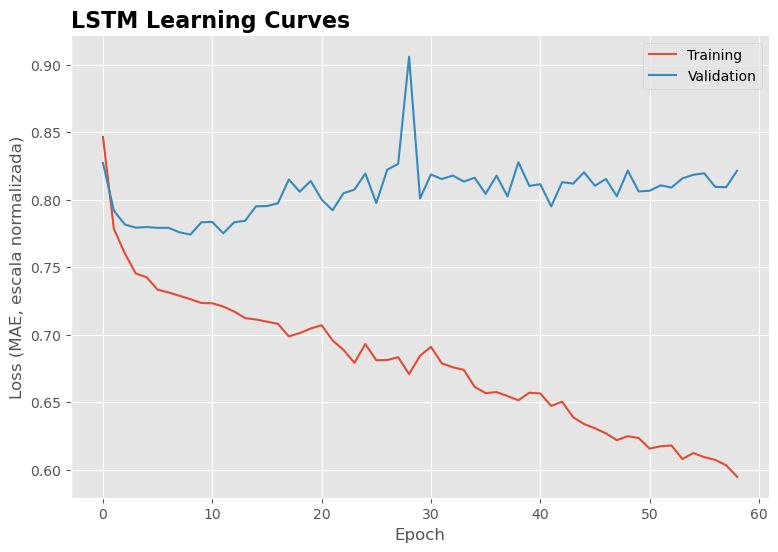

Best training loss   = 0.5948 at epoch 58
Best validation loss = 0.7742 at epoch 8


In [ ]:
# --- Curvas de aprendizaje ---
train_loss = history.history['loss']
val_loss = history.history['val_loss']

plt.style.use('ggplot')
fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(train_loss, label='Training')
ax.plot(val_loss, label='Validation')
ax.set_title('LSTM Learning Curves', loc='left', weight='bold', size=16)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss (MAE, escala normalizada)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend()
plt.show()

print(f'Best training loss   = {min(train_loss):.4f} at epoch {train_loss.index(min(train_loss))}')
print(f'Best validation loss = {min(val_loss):.4f} at epoch {val_loss.index(min(val_loss))}')

In [ ]:
# --- Prediccion y metricas LSTM multi-step, por horizonte (h=1..HORIZON) ---
# El modelo se entreno con el target NORMALIZADO (z-score, ver celda
# anterior), asi que predict() devuelve valores en esa misma escala. Hay que
# deshacer la normalizacion (lstm_target_mean/std, fit en train) antes de
# comparar contra y_train_lstm/y_test_lstm (escala ORIGINAL).
#
# Con salida multi-step, y_*_lstm y las predicciones tienen forma
# (n_samples, HORIZON, n_targets): se reportan metricas separadas POR PASO
# de horizonte (h=1 es la hora siguiente a la ventana, h=HORIZON la mas
# lejana) -- es habitual que el error crezca con el horizonte, y agregar
# todo junto esconde esa degradacion.
y_pred_train_lstm_scaled = lstm_model.predict(train_X_lstm)
y_pred_test_lstm_scaled = lstm_model.predict(test_X_lstm)

y_pred_train_lstm = y_pred_train_lstm_scaled * lstm_target_std.values + lstm_target_mean.values
y_pred_test_lstm = y_pred_test_lstm_scaled * lstm_target_std.values + lstm_target_mean.values

lstm_results = {}
for col_i, col in enumerate(TARGET):
    lstm_results[col] = {}
    for h in range(HORIZON):
        y_true_train_h = y_train_lstm[:, h, col_i]
        y_pred_train_h = y_pred_train_lstm[:, h, col_i]
        y_true_test_h = y_test_lstm[:, h, col_i]
        y_pred_test_h = y_pred_test_lstm[:, h, col_i]

        lstm_results[col][f'lstm_train_h{h + 1}'] = {
            'RMSE': mean_squared_error(y_true_train_h, y_pred_train_h) ** 0.5,
            'MAE': mean_absolute_error(y_true_train_h, y_pred_train_h),
            'R2': r2_score(y_true_train_h, y_pred_train_h),
        }
        lstm_results[col][f'lstm_test_h{h + 1}'] = {
            'RMSE': mean_squared_error(y_true_test_h, y_pred_test_h) ** 0.5,
            'MAE': mean_absolute_error(y_true_test_h, y_pred_test_h),
            'R2': r2_score(y_true_test_h, y_pred_test_h),
        }

# lstm_results['lstm_test'] / ['lstm_train'] = alias al horizonte h=1, para
# que la celda de comparativa final (que compara contra XGBoost/naive a 1
# paso) siga funcionando sin cambios.
for col in TARGET:
    lstm_results[col]['lstm_train'] = lstm_results[col]['lstm_train_h1']
    lstm_results[col]['lstm_test'] = lstm_results[col]['lstm_test_h1']

lstm_results_df = pd.DataFrame({(t, m): lstm_results[t][m] for t in lstm_results for m in lstm_results[t]})
print(lstm_results_df)


99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
     % Iron Concentrate                                    \
          lstm_train_h1 lstm_test_h1 lstm_train lstm_test   
RMSE           1.031149     1.134065   1.031149  1.134065   
MAE            0.788931     0.883886   0.788931  0.883886   
R2             0.119139    -0.035447   0.119139 -0.035447   

     % Silica Concentrate                                    
            lstm_train_h1 lstm_test_h1 lstm_train lstm_test  
RMSE             1.058707     1.130158   1.058707  1.130158  
MAE              0.767451     0.831856   0.767451  0.831856  
R2               0.102018     0.040970   0.102018  0.040970  


                                          RMSE       MAE        R2
target               method                                       
% Iron Concentrate   naive_constante  0.823104  0.577030  0.465612
                     naive_drift      1.347382  0.967575 -0.432067
                     xgboost_test     1.169105  0.906190 -0.078563
                     lstm_test        1.134065  0.883886 -0.035447
% Silica Concentrate naive_constante  0.729469  0.447335  0.604964
                     naive_drift      1.149918  0.722855  0.016879
                     xgboost_test     1.139122  0.901192  0.035701
                     lstm_test        1.130158  0.831856  0.040970


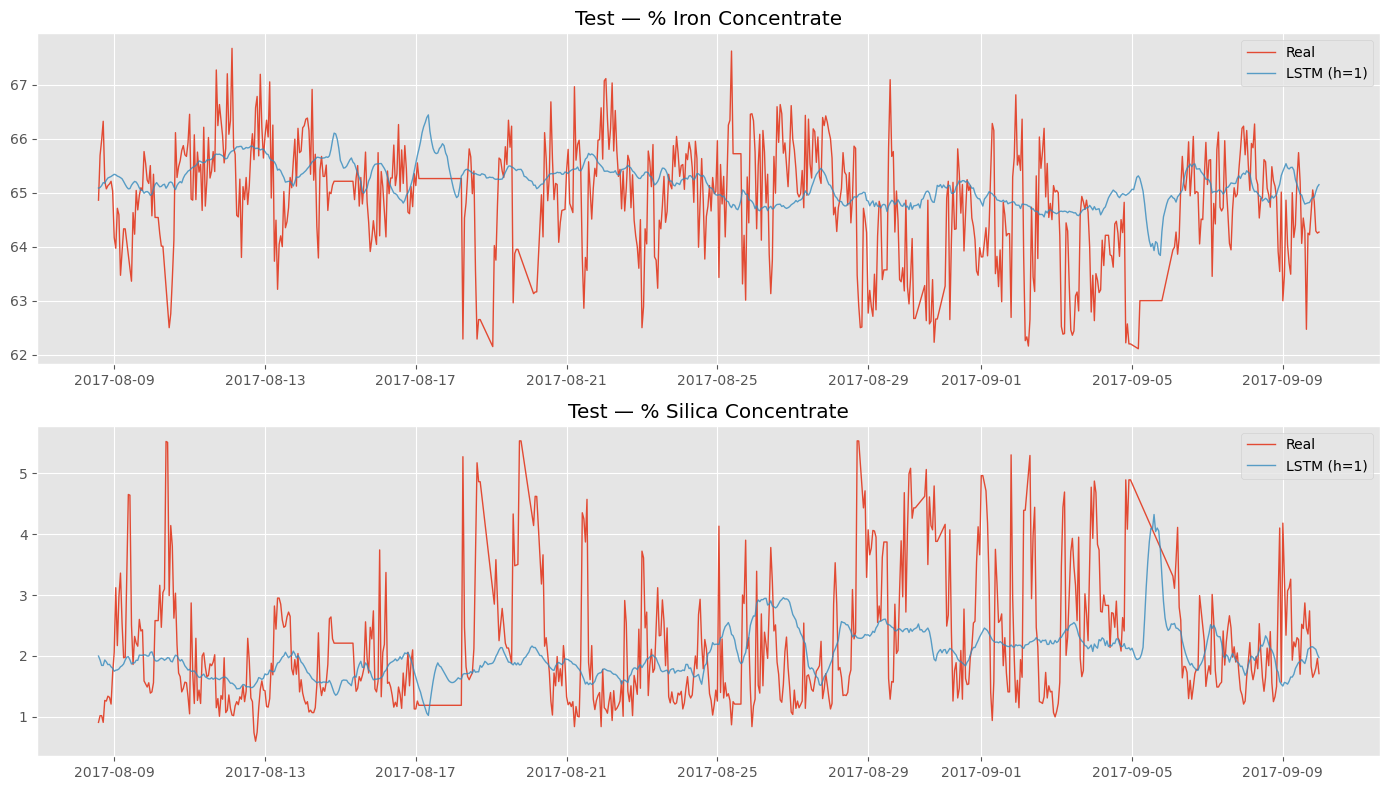

In [ ]:
# --- Comparativa final: LSTM vs. XGBoost vs. naive baselines (test), por target ---
# La comparativa usa el horizonte h=1 de la LSTM (lstm_results[col]['lstm_test'],
# alias de 'lstm_test_h1' -- ver celda anterior) para que sea comparable con
# XGBoost/naive, que solo predicen 1 paso adelante. El desglose completo por
# horizonte (h=1..HORIZON) esta en lstm_results_df de la celda anterior.
comparison_rows = []
for col in TARGET:
    for method, metrics in [
        ('naive_constante', naive_results[col]['naive_constante']),
        ('naive_drift', naive_results[col]['naive_drift']),
        ('xgboost_test', naive_results[col]['xgboost_test']),
        ('lstm_test', lstm_results[col]['lstm_test']),
    ]:
        comparison_rows.append({'target': col, 'method': method, **metrics})

comparison_df = pd.DataFrame(comparison_rows).set_index(['target', 'method'])
print(comparison_df)

# --- Graficas: real vs. predicho (test, horizonte h=1), LSTM vs. XGBoost ---
# y_test_lstm tiene forma (n_samples, HORIZON, n_targets); se grafica el
# paso h=1 (la prediccion a 1 hora, la mas comparable con XGBoost) usando
# test_idx_lstm como eje temporal (timestamp del primer paso predicho).
fig, axes = plt.subplots(len(TARGET), 1, figsize=(14, 4 * len(TARGET)))
for i, col in enumerate(TARGET):
    ax = axes[i] if len(TARGET) > 1 else axes
    ax.plot(test_idx_lstm, y_test_lstm[:, 0, i], label='Real', linewidth=1)
    # ax.plot(y_pred_model.index, y_pred_model[col], label='XGBoost', linewidth=1, alpha=0.8)
    ax.plot(test_idx_lstm, y_pred_test_lstm[:, 0, i], label='LSTM (h=1)', linewidth=1, alpha=0.8)
    ax.set_title(f'Test — {col}')
    ax.legend()

plt.tight_layout()
plt.show()
